# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

print("Warnings imported successfully.")

Warnings imported successfully.


In [ ]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)
print("geopandas version:", gpd.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2
geopandas version: 1.1.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/Assignments/EDA/data_NYC_Taxi/trip_records')

# Used below code in execution, will comment after use and uncomment above code as suggested by assignment
# Check if the directory exists before changing
#if not os.path.exists('/content/drive/MyDrive/Colab Notebooks/AICode/AICode586/EDA/EDA_DATA_NYC/trip_records'):
#    print("Directory not found. Please ensure Google Drive is mounted and the path is correct.")
#else:
#    os.chdir('/content/drive/MyDrive/Colab Notebooks/AICode/AICode586/EDA/EDA_DATA_NYC/trip_records')
#    print(f"Changed directory to: {os.getcwd()}")

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        current_month_df = pd.read_parquet(file_path)

        # Ensure tpep_pickup_datetime is in datetime format
        current_month_df['tpep_pickup_datetime'] = pd.to_datetime(current_month_df['tpep_pickup_datetime'])

        # Extract date and hour
        current_month_df['pickup_date'] = current_month_df['tpep_pickup_datetime'].dt.date
        current_month_df['pickup_hour'] = current_month_df['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        unique_dates = current_month_df['pickup_date'].unique()
        for date in unique_dates:
            # Iterate through each hour of the selected date
            for hour in range(24):
              # Filter data for the current date and hour
                hour_data = current_month_df[(current_month_df['pickup_date'] == date) & (current_month_df['pickup_hour'] == hour)]

                # Sample 5% of the hourly data randomly
                if not hour_data.empty:
                    sample = hour_data.sample(frac=0.05, random_state=42)
                    sampled_data = pd.concat([sampled_data, sample], ignore_index=True)  # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True) # we initialised this empty DF earlier
        print(f'Finished processing {file_name}. Total sampled rows so far: {len(df)}')

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

sampled_data_month = pd.DataFrame()
sampled_data_month = sampled_data
print(f"Data sampling complete. Final DataFrame has {len(df)} rows.")

# Drop temporary columns
df.drop(columns=['pickup_date', 'pickup_hour'], inplace=True, errors='ignore')

Changed directory to: /content/drive/MyDrive/Colab Notebooks/AICode/AICode586/EDA/EDA_DATA_NYC/trip_records
Finished processing 2023-1.parquet. Total sampled rows so far: 152087
Error reading file .ipynb_checkpoints: 'tpep_pickup_datetime'
Data sampling complete. Final DataFrame has 152087 rows.


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
# df.to_parquet('')
df.to_parquet('sampled_2023_taxi_data.parquet', index=False)
print("Sampled data saved to 'sampled_2023_taxi_data.parquet'")

Sampled data saved to 'sampled_2023_taxi_data.parquet'


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file
df = pd.read_parquet('sampled_2023_taxi_data.parquet')
print("Sampled data loaded successfully.")

Sampled data loaded successfully.


In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152087 entries, 0 to 152086
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               152087 non-null  int64         
 1   tpep_pickup_datetime   152087 non-null  datetime64[us]
 2   tpep_dropoff_datetime  152087 non-null  datetime64[us]
 3   passenger_count        148483 non-null  float64       
 4   trip_distance          152087 non-null  float64       
 5   RatecodeID             148483 non-null  float64       
 6   store_and_fwd_flag     148483 non-null  object        
 7   PULocationID           152087 non-null  int64         
 8   DOLocationID           152087 non-null  int64         
 9   payment_type           152087 non-null  int64         
 10  fare_amount            152087 non-null  float64       
 11  extra                  152087 non-null  float64       
 12  mta_tax                152087 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)

# Standardize column names to snake_case
df.rename(columns={
    'VendorID': 'vendor_id',
    'RatecodeID': 'ratecode_id',
    'PULocationID': 'pu_location_id',
    'DOLocationID': 'do_location_id'
}, inplace=True)

print("DataFrame index reset and column names standardized.")
print(df.columns.tolist())


DataFrame index reset and column names standardized.
['vendor_id', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecode_id', 'store_and_fwd_flag', 'pu_location_id', 'do_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns
print("Checking for multiple airport fee columns:")
airport_fee_cols = [col for col in df.columns if 'airport_fee' in col]

if len(airport_fee_cols) > 1:
    print(f"Found multiple airport fee columns: {airport_fee_cols}")

    # Check columns are numeric and handle NaNs
    for col in airport_fee_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0) # Convert to numeric, NaN to 0

    # Combine the columns
    df['airport_fee'] = df[airport_fee_cols].sum(axis=1)

    # Drop the original
    df.drop(columns=airport_fee_cols, inplace=True)
    print("Multiple airport fee columns combined into a single 'airport_fee' column.")
elif len(airport_fee_cols) == 1:
    print(f"Only one 'airport_fee' column found: {airport_fee_cols[0]}")
    # Check airport_fee column
    if airport_fee_cols[0] != 'airport_fee':
        df.rename(columns={airport_fee_cols[0]: 'airport_fee'}, inplace=True)
        print(f"Renamed '{airport_fee_cols[0]}' to 'airport_fee'.")
    df['airport_fee'] = pd.to_numeric(df['airport_fee'], errors='coerce').fillna(0) # Ensure numeric type
else:
    print("No 'airport_fee' columns found.")

print("Current DataFrame columns after processing airport fees:")
print(df.columns.tolist())



Checking for multiple airport fee columns:
Only one 'airport_fee' column found: airport_fee
Current DataFrame columns after processing airport fees:
['vendor_id', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecode_id', 'store_and_fwd_flag', 'pu_location_id', 'do_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check columns where amount are negative
print("Checking for negative values in monetary columns:")
monetary_columns = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

for col in monetary_columns:
    negative_count = df[df[col] < 0].shape[0]
    if negative_count > 0:
        print(f"Column '{col}' has {negative_count} negative values.")
    else:
        print(f"Column '{col}' has no negative values.")


Checking for negative values in monetary columns:
Column 'fare_amount' has no negative values.
Column 'extra' has no negative values.
Column 'mta_tax' has 6 negative values.
Column 'tip_amount' has no negative values.
Column 'tolls_amount' has no negative values.
Column 'improvement_surcharge' has 7 negative values.
Column 'total_amount' has 7 negative values.
Column 'congestion_surcharge' has 6 negative values.
Column 'airport_fee' has 1 negative values.


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts

print("\nRecords where 'fare_amount' is negative:")
print(df[df['fare_amount'] < 0].head())

print("Checking RatecodeID for negative fare amounts:")
print(df[df['fare_amount'] < 0]['ratecode_id'].value_counts())



Records where 'fare_amount' is negative:
Empty DataFrame
Columns: [vendor_id, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, ratecode_id, store_and_fwd_flag, pu_location_id, do_location_id, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, airport_fee]
Index: []
Checking RatecodeID for negative fare amounts:
Series([], Name: count, dtype: int64)


In [ ]:
# Find which columns have negative values
print("Checking for negative values in monetary columns:")
numeric_df = df.select_dtypes(include=np.number)
negative_columns = numeric_df.columns[(numeric_df < 0).any()]

print(negative_columns)

Checking for negative values in monetary columns:
Index(['mta_tax', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee'],
      dtype='object')


In [ ]:
# fix these negative values
monetary_columns_to_fix = ['mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

for col in monetary_columns_to_fix:
    initial_negative_count = df[df[col] < 0].shape[0]
    if initial_negative_count > 0:
        df[col] = df[col].apply(lambda x: max(x, 0)) # Replace negative values with 0
        final_negative_count = df[df[col] < 0].shape[0]
        print(f"Fixed negative values in '{col}': {initial_negative_count} values changed. Remaining negative values: {final_negative_count}")
    else:
        print(f"No negative values found in '{col}' to fix.")

print("\nRe-checking monetary columns for negative values after fix:")
for col in monetary_columns:
    negative_count = df[df[col] < 0].shape[0]
    if negative_count > 0:
        print(f"Column '{col}' still has {negative_count} negative values.")
    else:
        print(f"Column '{col}' now has no negative values.")


Fixed negative values in 'mta_tax': 6 values changed. Remaining negative values: 0
Fixed negative values in 'improvement_surcharge': 7 values changed. Remaining negative values: 0
Fixed negative values in 'total_amount': 7 values changed. Remaining negative values: 0
Fixed negative values in 'congestion_surcharge': 6 values changed. Remaining negative values: 0
Fixed negative values in 'airport_fee': 1 values changed. Remaining negative values: 0

Re-checking monetary columns for negative values after fix:
Column 'fare_amount' now has no negative values.
Column 'extra' now has no negative values.
Column 'mta_tax' now has no negative values.
Column 'tip_amount' now has no negative values.
Column 'tolls_amount' now has no negative values.
Column 'improvement_surcharge' now has no negative values.
Column 'total_amount' now has no negative values.
Column 'congestion_surcharge' now has no negative values.
Column 'airport_fee' now has no negative values.


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column
missing_values_count = df.isnull().sum()
total_rows = len(df)
missing_values_proportion = (missing_values_count / total_rows) * 100

print("Proportion of Missing Values (%):\n")
print(missing_values_proportion[missing_values_proportion > 0].sort_values(ascending=False))


Proportion of Missing Values (%):

passenger_count         2.369696
ratecode_id             2.369696
store_and_fwd_flag      2.369696
congestion_surcharge    2.369696
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
print("Rows with null values in 'passenger_count':")
print(df[df['passenger_count'].isnull()].head())

# Impute NaN values in 'passenger_count' with the mode
mode_passenger_count = df['passenger_count'].mode()[0]
print(f"\nMode of 'passenger_count': {mode_passenger_count}")
df['passenger_count'].fillna(mode_passenger_count, inplace=True)
print("\nNaN values in 'passenger_count' have been imputed with the mode.")

# Check if there are any remaining nulls in 'passenger_count'
print(f"Missing values in 'passenger_count' after imputation: {df['passenger_count'].isnull().sum()}")

Rows with null values in 'passenger_count':
    vendor_id tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
4           2  2023-01-01 00:43:00   2023-01-01 01:01:00              NaN   
15          2  2023-01-01 00:41:50   2023-01-01 01:14:50              NaN   
42          2  2023-01-01 00:37:21   2023-01-01 00:54:18              NaN   
43          2  2023-01-01 00:44:03   2023-01-01 01:13:49              NaN   
46          2  2023-01-01 00:50:55   2023-01-01 01:19:06              NaN   

    trip_distance  ratecode_id store_and_fwd_flag  pu_location_id  \
4           19.24          NaN               None              66   
15          10.77          NaN               None             151   
42           4.52          NaN               None             114   
43           9.19          NaN               None             239   
46           2.74          NaN               None              90   

    do_location_id  payment_type  fare_amount  extra  mta_tax  tip_amount  \
4

Did you find zeroes in passenger_count? Handle these.

In [ ]:
# Check for zero values in 'passenger_count'
zero_passenger_count = df[df['passenger_count'] == 0].shape[0]
print(f"Number of records with 0 passengers: {zero_passenger_count}")

Number of records with 0 passengers: 2608


In [ ]:
if zero_passenger_count > 0:
    # Replacing 0 passenger counts with 1 (the mode)
    df['passenger_count'] = df['passenger_count'].replace(0, 1)
    print("Replaced 0 passenger counts with 1.")

# Verify that there are no more 0 passenger counts
print(f"Number of records with 0 passengers after fix: {df[df['passenger_count'] == 0].shape[0]}")

Replaced 0 passenger counts with 1.
Number of records with 0 passengers after fix: 0


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
print("Rows with null values in 'ratecode_id':")
print(df[df['ratecode_id'].isnull()].head())

# Impute NaN values in 'ratecode_id' with mode
mode_ratecode_id = df['ratecode_id'].mode()[0]
print(f"\nMode of 'ratecode_id': {mode_ratecode_id}")
df['ratecode_id'].fillna(mode_ratecode_id, inplace=True)
print("\nNaN values in 'ratecode_id' have been imputed with the mode.")

print(f"Missing values in 'ratecode_id' after imputation: {df['ratecode_id'].isnull().sum()}")

Rows with null values in 'ratecode_id':
    vendor_id tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
4           2  2023-01-01 00:43:00   2023-01-01 01:01:00              1.0   
15          2  2023-01-01 00:41:50   2023-01-01 01:14:50              1.0   
42          2  2023-01-01 00:37:21   2023-01-01 00:54:18              1.0   
43          2  2023-01-01 00:44:03   2023-01-01 01:13:49              1.0   
46          2  2023-01-01 00:50:55   2023-01-01 01:19:06              1.0   

    trip_distance  ratecode_id store_and_fwd_flag  pu_location_id  \
4           19.24          NaN               None              66   
15          10.77          NaN               None             151   
42           4.52          NaN               None             114   
43           9.19          NaN               None             239   
46           2.74          NaN               None              90   

    do_location_id  payment_type  fare_amount  extra  mta_tax  tip_amount  \
4    

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge
print("Unique values in 'congestion_surcharge' before imputation:")
print(df['congestion_surcharge'].value_counts(dropna=False))

# NaN implying no charge hence imputing NaN values with 0
df['congestion_surcharge'].fillna(0, inplace=True)
print("\nNaN values in 'congestion_surcharge' have been imputed with 0.")

print(f"Missing values in 'congestion_surcharge' after imputation: {df['congestion_surcharge'].isnull().sum()}")


Unique values in 'congestion_surcharge' before imputation:
congestion_surcharge
2.5    137212
0.0     11271
NaN      3604
Name: count, dtype: int64

NaN values in 'congestion_surcharge' have been imputed with 0.
Missing values in 'congestion_surcharge' after imputation: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values
print("Rows with null values in 'store_and_fwd_flag':")
print(df[df['store_and_fwd_flag'].isnull()].head())

# Impute NaN values in 'store_and_fwd_flag' with 'N'
mode_store_and_fwd_flag = df['store_and_fwd_flag'].mode()[0]
print(f"\nMode of 'store_and_fwd_flag': {mode_store_and_fwd_flag}")
df['store_and_fwd_flag'].fillna(mode_store_and_fwd_flag, inplace=True)
print("\nNaN values in 'store_and_fwd_flag' have been imputed with the mode.")

print(f"\nTotal missing values in DataFrame after all imputations: {df.isnull().sum().sum()}")


Rows with null values in 'store_and_fwd_flag':
    vendor_id tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
4           2  2023-01-01 00:43:00   2023-01-01 01:01:00              1.0   
15          2  2023-01-01 00:41:50   2023-01-01 01:14:50              1.0   
42          2  2023-01-01 00:37:21   2023-01-01 00:54:18              1.0   
43          2  2023-01-01 00:44:03   2023-01-01 01:13:49              1.0   
46          2  2023-01-01 00:50:55   2023-01-01 01:19:06              1.0   

    trip_distance  ratecode_id store_and_fwd_flag  pu_location_id  \
4           19.24          1.0               None              66   
15          10.77          1.0               None             151   
42           4.52          1.0               None             114   
43           9.19          1.0               None             239   
46           2.74          1.0               None              90   

    do_location_id  payment_type  fare_amount  extra  mta_tax  tip_amount  

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
print("Descriptive statistics for numerical columns:")
print(df.describe().T)
# Check for potential out of place values in various columns
print("\nValue counts for key categorical/numerical columns to check for anomalies:")
print("Passenger count distribution:\n", df['passenger_count'].value_counts())
print("\nTrip distance statistics:\n", df['trip_distance'].describe())
print("\nFare amount statistics:\n", df['fare_amount'].describe())
print("\nPayment type distribution:\n", df['payment_type'].value_counts())
print("\nRatecodeID distribution:\n", df['ratecode_id'].value_counts())



Descriptive statistics for numerical columns:
                          count                        mean  \
vendor_id              152087.0                     1.72356   
tpep_pickup_datetime     152087  2023-01-17 00:31:22.761406   
tpep_dropoff_datetime    152087  2023-01-17 00:46:55.277084   
passenger_count        152087.0                     1.37113   
trip_distance          152087.0                     3.47172   
ratecode_id            152087.0                      1.4648   
pu_location_id         152087.0                  166.427874   
do_location_id         152087.0                  164.514061   
payment_type           152087.0                    1.176938   
fare_amount            152087.0                   18.607735   
extra                  152087.0                    1.569767   
mta_tax                152087.0                    0.496299   
tip_amount             152087.0                     3.38848   
tolls_amount           152087.0                    0.525836   
improveme

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
initial_rows = len(df)
df = df[df['passenger_count'] <= 6]
print(f"Removed {initial_rows - len(df)} rows where passenger_count was greater than 6.")
print(f"DataFrame now has {len(df)} rows.")

Removed 1 rows where passenger_count was greater than 6.
DataFrame now has 152086 rows.


In [ ]:
# Continue with outlier handling
print("Handling outliers...")
initial_rows = len(df)

# 1. Entries where trip_distance is nearly 0 and fare_amount is more than 300
print(f"Trips with trip_distance < 0.1 and fare_amount > 300: {df[(df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)].shape[0]} records")
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]
print(f"Removed records where trip_distance < 0.1 and fare_amount > 300. New rows: {len(df)}")

# 2. Entries where trip_distance and fare_amount are 0 but PULocationID and DOLocationID are different
problematic_trips = df[(df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['pu_location_id'] != df['do_location_id'])]
print(f"\nTrips with trip_distance=0, fare_amount=0, but different PU/DO locations: {problematic_trips.shape[0]} records")
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['pu_location_id'] != df['do_location_id']))]
print(f"Removed problematic trips. New rows: {len(df)}")


# 3. Entries where trip_distance is more than 250 miles.
print(f"\nTrips with trip_distance > 250 miles: {df[df['trip_distance'] > 250].shape[0]} records")
df = df[df['trip_distance'] <= 250]
print(f"Removed trips with trip_distance > 250 miles. New rows: {len(df)}")

# 4. Entries where payment_type is 0 (not defined in the data dictionary).
print(f"\nTrips with undefined payment_type (0): {df[df['payment_type'] == 0].shape[0]} records")
df = df[df['payment_type'] != 0]
print(f"Removed trips with payment_type 0. New rows: {len(df)}")


final_removed_rows = initial_rows - len(df)
print(f"\nTotal rows removed during outlier handling: {final_removed_rows}")
print(f"DataFrame now has {len(df)} rows after outlier handling.")



Handling outliers...
Trips with trip_distance < 0.1 and fare_amount > 300: 3 records
Removed records where trip_distance < 0.1 and fare_amount > 300. New rows: 152083

Trips with trip_distance=0, fare_amount=0, but different PU/DO locations: 5 records
Removed problematic trips. New rows: 152078

Trips with trip_distance > 250 miles: 4 records
Removed trips with trip_distance > 250 miles. New rows: 152074

Trips with undefined payment_type (0): 3600 records
Removed trips with payment_type 0. New rows: 148474

Total rows removed during outlier handling: 3612
DataFrame now has 148474 rows after outlier handling.


In [ ]:
# Do any columns need standardising?
print("Descriptive statistics for numerical columns:")
print(df.describe().T)

# Identify numerical columns for potential scaling
scalable_columns = [
    'trip_distance',
    'fare_amount',
    'extra',
    'tip_amount',
    'tolls_amount',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

# Review distributions for these columns.# Apply MinMaxScaler to selected columns, creating new scaled columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

for col in scalable_columns:
    # Reshape for scaler and apply, then add as a new column
    df[f'{col}_scaled'] = scaler.fit_transform(df[[col]])
    print(f"Scaled '{col}' to '{col}_scaled' using MinMaxScaler.")

print("\nDataFrame head with new scaled columns:")
print(df.head())

print("\nDescriptive statistics for scaled columns:")
print(df[[f'{col}_scaled' for col in scalable_columns]].describe().T)


Descriptive statistics for numerical columns:
                          count                        mean  \
vendor_id              148474.0                    1.724962   
tpep_pickup_datetime     148474  2023-01-17 00:40:36.205281   
tpep_dropoff_datetime    148474  2023-01-17 00:56:07.309758   
passenger_count        148474.0                    1.380093   
trip_distance          148474.0                    3.364036   
ratecode_id            148474.0                    1.475342   
pu_location_id         148474.0                  166.505967   
do_location_id         148474.0                  164.576337   
payment_type           148474.0                    1.205484   
fare_amount            148474.0                   18.543071   
extra                  148474.0                    1.602692   
mta_tax                148474.0                    0.496256   
tip_amount             148474.0                     3.37998   
tolls_amount           148474.0                    0.527192   
improveme

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['vendor_id',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'ratecode_id',
 'store_and_fwd_flag',
 'pu_location_id',
 'do_location_id',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_distance_scaled',
 'fare_amount_scaled',
 'extra_scaled',
 'tip_amount_scaled',
 'tolls_amount_scaled',
 'total_amount_scaled',
 'congestion_surcharge_scaled',
 'airport_fee_scaled']

In [ ]:
# Print column names and their data types to assist in categorization
print("DataFrame Columns and their dtypes:")
print(df.info())

DataFrame Columns and their dtypes:
<class 'pandas.core.frame.DataFrame'>
Index: 148474 entries, 0 to 152086
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   vendor_id                    148474 non-null  int64         
 1   tpep_pickup_datetime         148474 non-null  datetime64[us]
 2   tpep_dropoff_datetime        148474 non-null  datetime64[us]
 3   passenger_count              148474 non-null  float64       
 4   trip_distance                148474 non-null  float64       
 5   ratecode_id                  148474 non-null  float64       
 6   store_and_fwd_flag           148474 non-null  object        
 7   pu_location_id               148474 non-null  int64         
 8   do_location_id               148474 non-null  int64         
 9   payment_type                 148474 non-null  int64         
 10  fare_amount                  148474 non-null  float64       


#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [ ]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour


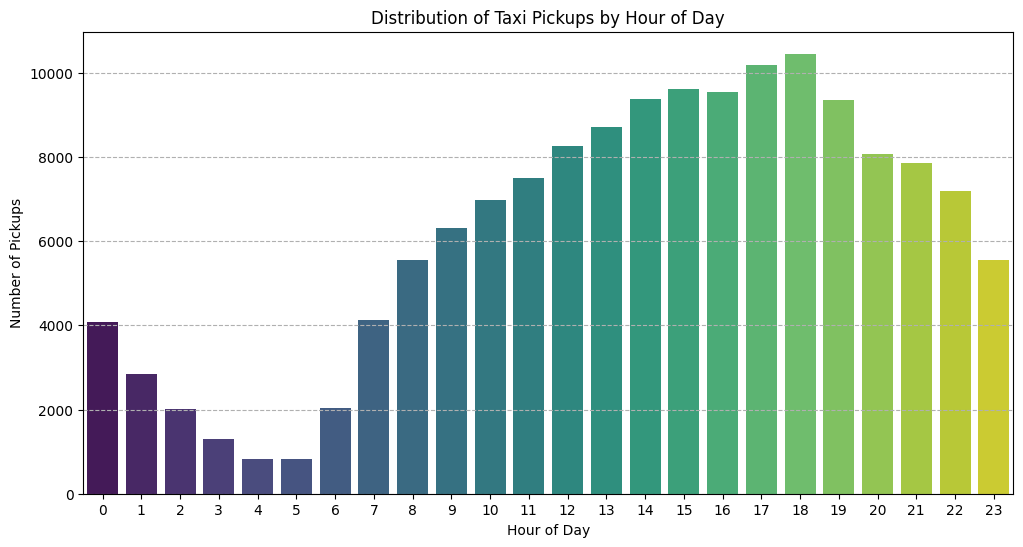

Hourly pickup distribution plotted successfully.


In [ ]:
# Calculate and visualize hourly trends in taxi pickups
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_hour', data=df, palette='viridis')
plt.title('Distribution of Taxi Pickups by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--')
plt.show()

print("Hourly pickup distribution plotted successfully.")

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['pickup_day_of_week'] = pd.Categorical(df['pickup_day_of_week'], categories=day_order, ordered=True)


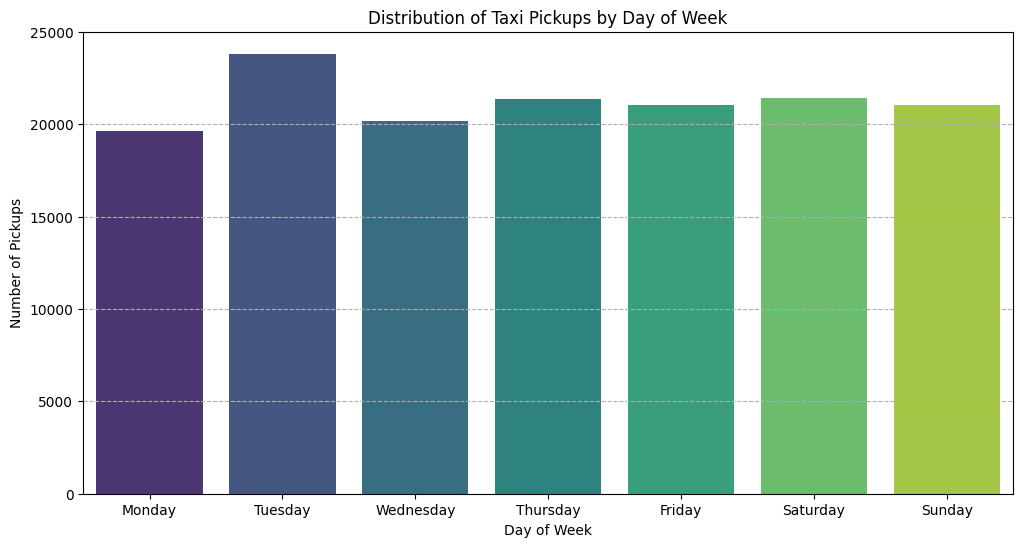

Daily pickup distribution plotted successfully.


In [ ]:
# Calculate and visualize daily trends in taxi pickups
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_day_of_week', data=df, palette='viridis')
plt.title('Distribution of Taxi Pickups by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.grid(axis='y', linestyle='--')
plt.show()

print("Daily pickup distribution plotted successfully.")

In [ ]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['pickup_month'] = pd.Categorical(df['pickup_month'], categories=month_order, ordered=True)


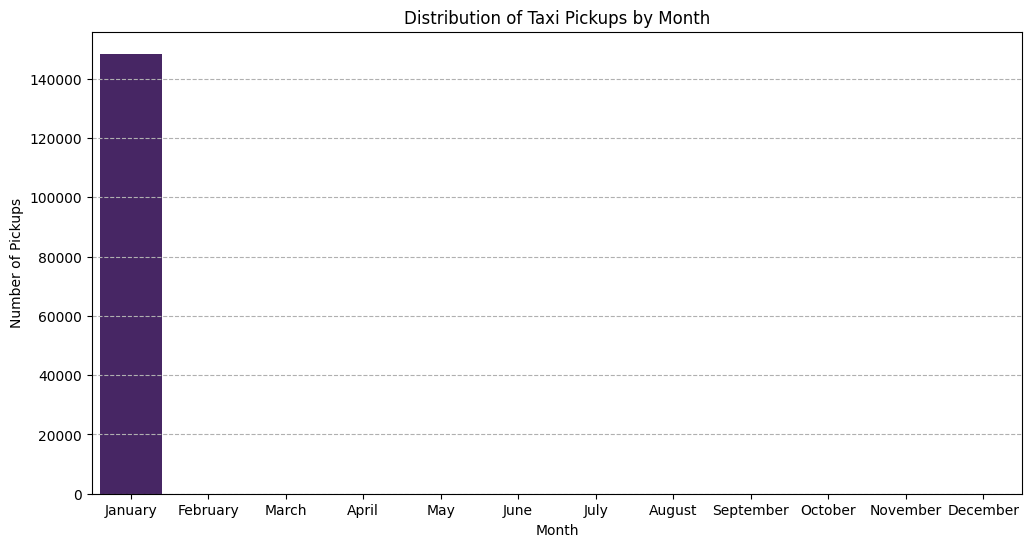

Monthly pickup distribution plotted successfully.


In [ ]:
# Show the monthly trends in pickups
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_month', data=df, palette='viridis')
plt.title('Distribution of Taxi Pickups by Month')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.grid(axis='y', linestyle='--')
plt.show()

print("Monthly pickup distribution plotted successfully.")

In [ ]:
print("Extracted 'pickup_hour', 'pickup_day_of_week', and 'pickup_month' columns.")
print(df[['tpep_pickup_datetime', 'pickup_hour', 'pickup_day_of_week', 'pickup_month']].head())

Extracted 'pickup_hour', 'pickup_day_of_week', and 'pickup_month' columns.
  tpep_pickup_datetime  pickup_hour pickup_day_of_week pickup_month
0  2023-01-01 00:07:18            0             Sunday      January
1  2023-01-01 00:16:41            0             Sunday      January
2  2023-01-01 00:14:03            0             Sunday      January
3  2023-01-01 00:24:30            0             Sunday      January
5  2023-01-01 00:42:56            0             Sunday      January


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters
financial_parameters = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

print("Checking for zero values in financial parameters:")
for col in financial_parameters:
    zero_count = (df[col] == 0).sum()
    print(f"Column '{col}' has {zero_count} zero values.")


Checking for zero values in financial parameters:
Column 'fare_amount' has 56 zero values.
Column 'tip_amount' has 33206 zero values.
Column 'total_amount' has 37 zero values.
Column 'trip_distance' has 1871 zero values.


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.
print("Original DataFrame shape:", df.shape)

# Create a new DataFrame with non-zero entries for the selected parameters
df_filtered_financial = df[(df['fare_amount'] > 0) &
                           (df['tip_amount'] > 0) &
                           (df['total_amount'] > 0) &
                           (df['trip_distance'] > 0)].copy()

print("New DataFrame shape after filtering for non-zero financial parameters:", df_filtered_financial.shape)
print(f"Number of rows removed: {df.shape[0] - df_filtered_financial.shape[0]}")


Original DataFrame shape: (148474, 30)
New DataFrame shape after filtering for non-zero financial parameters: (114599, 30)
Number of rows removed: 33875


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

Monthly Revenue Trend:
   pickup_month_num  total_amount month_name
0                 1    3216268.43    January
1                12         13.50   December


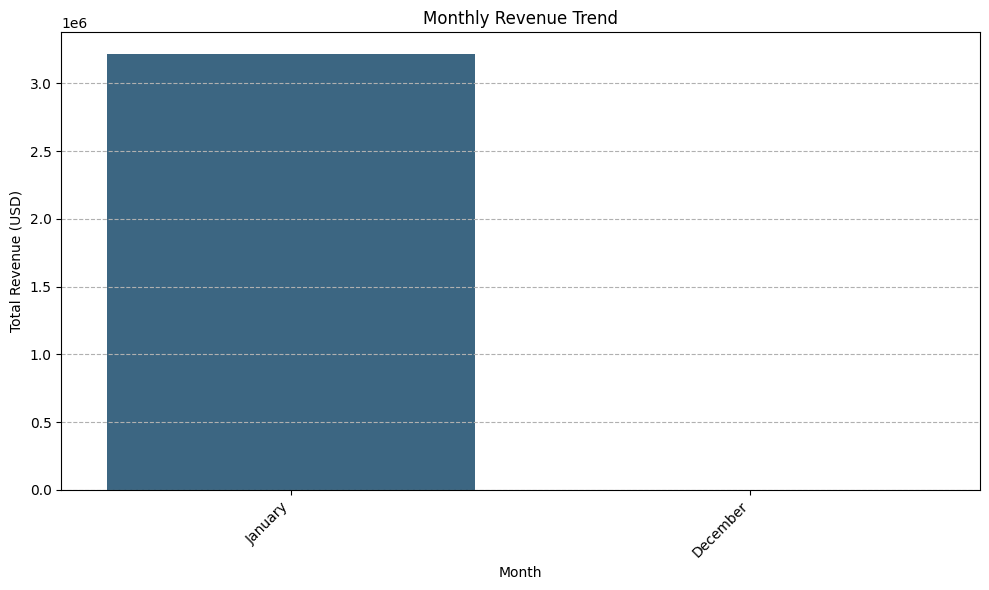

In [ ]:
# Group data by month and analyse monthly revenue
# Ensure 'tpep_pickup_datetime' is datetime type
df_filtered_financial['tpep_pickup_datetime'] = pd.to_datetime(df_filtered_financial['tpep_pickup_datetime'])

# Extract month for grouping
df_filtered_financial['pickup_month_num'] = df_filtered_financial['tpep_pickup_datetime'].dt.month

monthly_revenue = df_filtered_financial.groupby('pickup_month_num')['total_amount'].sum().reset_index()
monthly_revenue['month_name'] = monthly_revenue['pickup_month_num'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%B'))

print("Monthly Revenue Trend:")
print(monthly_revenue)

# Plotting the monthly revenue
plt.figure(figsize=(10, 6))
sns.barplot(x='month_name', y='total_amount', data=monthly_revenue, palette='viridis')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()



**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

Quarterly Revenue Proportion:
   pickup_quarter  total_amount  revenue_proportion
0               1    3216268.43            99.99958
1               4         13.50             0.00042


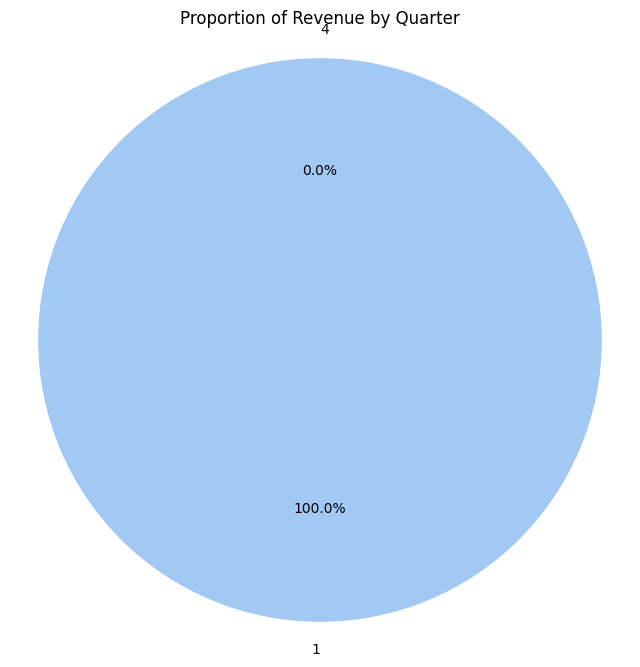

In [ ]:
# Calculate proportion of each quarter
df_filtered_financial['pickup_quarter'] = df_filtered_financial['tpep_pickup_datetime'].dt.quarter

quarterly_revenue = df_filtered_financial.groupby('pickup_quarter')['total_amount'].sum().reset_index()
total_annual_revenue = quarterly_revenue['total_amount'].sum()
quarterly_revenue['revenue_proportion'] = (quarterly_revenue['total_amount'] / total_annual_revenue) * 100

print("Quarterly Revenue Proportion:")
print(quarterly_revenue)

# Plotting the quarterly revenue proportion
plt.figure(figsize=(8, 8))
plt.pie(quarterly_revenue['revenue_proportion'], labels=quarterly_revenue['pickup_quarter'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Proportion of Revenue by Quarter')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

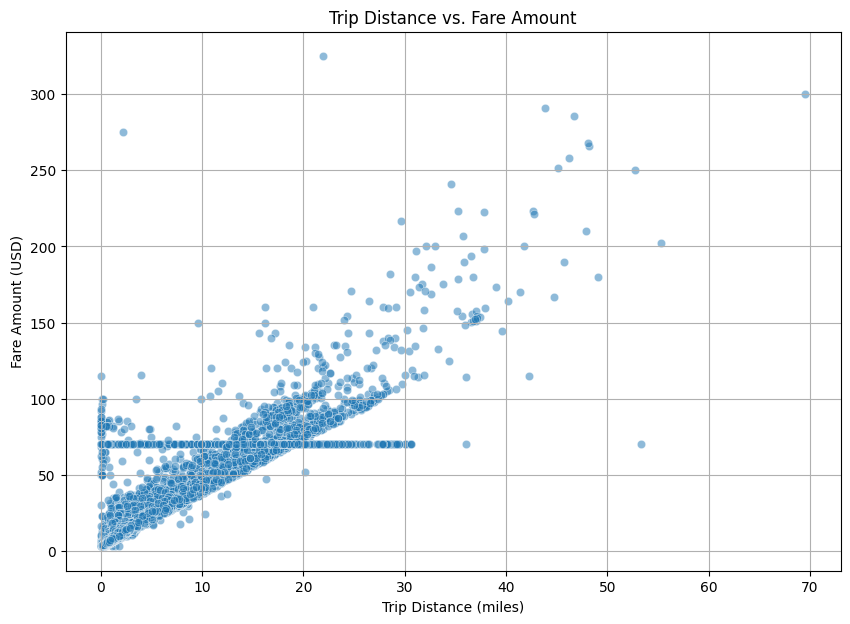

Correlation between Trip Distance and Fare Amount: 0.96


In [ ]:
# Show how trip fare is affected by distance
df_distance_fare = df_filtered_financial[df_filtered_financial['trip_distance'] > 0].copy()

# Plotting the relationship using a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_distance_fare, alpha=0.5)
plt.title('Trip Distance vs. Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount (USD)')
plt.grid(True)
plt.show()

# Calculate the correlation between trip_distance and fare_amount
correlation = df_distance_fare['trip_distance'].corr(df_distance_fare['fare_amount'])
print(f"Correlation between Trip Distance and Fare Amount: {correlation:.2f}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [ ]:
(df_filtered_financial['tpep_dropoff_datetime'] - df_filtered_financial['tpep_pickup_datetime']).dt.total_seconds() / 60

,0
1,5.083333
5,33.616667
6,10.516667
7,15.883333
8,17.133333
...,...
152080,43.683333
152081,6.066667
152084,5.216667
152085,11.866667


In [ ]:
#df_filtered_financial['trip_duration_minutes'] = (df_filtered_financial['tpep_dropoff_datetime'] - df_filtered_financial['tpep_pickup_datetime']).dt.total_seconds() / 60

In [ ]:
df_filtered_financial[(df_filtered_financial['trip_duration_minutes'] > 1) & (df_filtered_financial['trip_duration_minutes'] < 180)]

,vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode_id,store_and_fwd_flag,pu_location_id,do_location_id,payment_type,...,tolls_amount_scaled,total_amount_scaled,congestion_surcharge_scaled,airport_fee_scaled,pickup_hour,pickup_day_of_week,pickup_month,pickup_month_num,pickup_quarter,trip_duration_minutes
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.0,0.025479,1.0,0.0,0,Sunday,January,1,1,5.083333
5,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,0.0,0.078018,1.0,0.0,0,Sunday,January,1,1,33.616667
6,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,N,79,164,1,...,0.0,0.032392,1.0,0.0,0,Sunday,January,1,1,10.516667
7,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,N,79,256,1,...,0.0,0.049576,1.0,0.0,0,Sunday,January,1,1,15.883333
8,2,2023-01-01 00:44:09,2023-01-01 01:01:17,1.0,7.64,1.0,N,132,95,1,...,0.0,0.070019,0.0,1.0,0,Sunday,January,1,1,17.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152080,2,2023-01-31 23:50:17,2023-02-01 00:33:58,4.0,16.79,1.0,N,132,145,1,...,0.0,0.140482,0.0,1.0,23,Tuesday,January,1,1,43.683333
152081,2,2023-01-31 23:25:34,2023-01-31 23:31:38,1.0,1.84,1.0,N,236,239,1,...,0.0,0.029627,1.0,0.0,23,Tuesday,January,1,1,6.066667
152084,2,2023-01-31 23:35:26,2023-01-31 23:40:39,1.0,0.87,1.0,N,79,148,1,...,0.0,0.024097,1.0,0.0,23,Tuesday,January,1,1,5.216667
152085,2,2023-01-31 23:12:04,2023-01-31 23:23:56,1.0,2.53,1.0,N,90,148,1,...,0.0,0.037923,1.0,0.0,23,Tuesday,January,1,1,11.866667


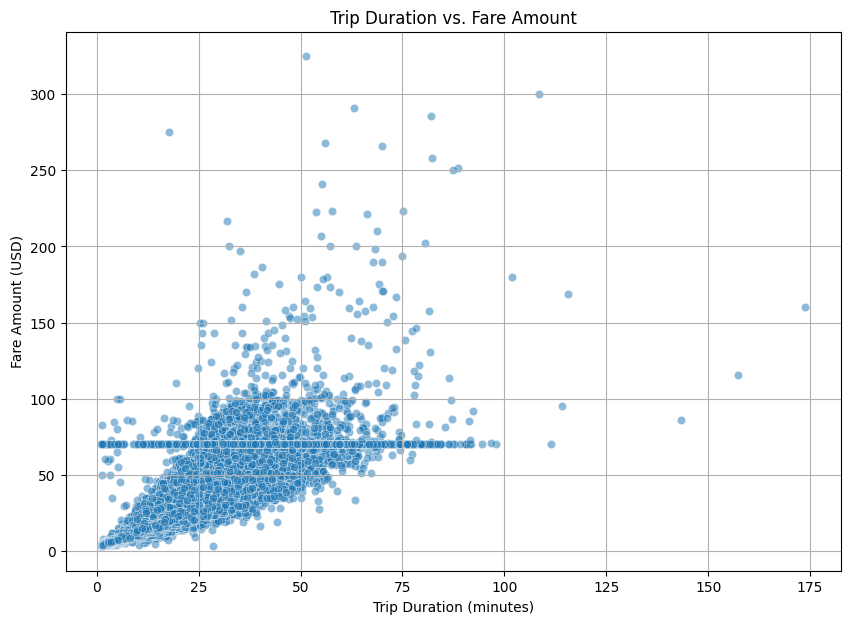

Correlation between Fare Amount and Trip Duration: 0.87


In [ ]:
# Show relationship between fare and trip duration

# Calculate trip duration in minutes
df_filtered_financial['trip_duration_minutes'] = (df_filtered_financial['tpep_dropoff_datetime'] - df_filtered_financial['tpep_pickup_datetime']).dt.total_seconds() / 60

# Filter out extremely long or short durations which might be outliers for better visualization
df_duration_fare = df_filtered_financial[(df_filtered_financial['trip_duration_minutes'] > 1) & (df_filtered_financial['trip_duration_minutes'] < 180)].copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(x='trip_duration_minutes', y='fare_amount', data=df_duration_fare, alpha=0.5)
plt.title('Trip Duration vs. Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount (USD)')
plt.grid(True)
plt.show()

correlation_fare_duration = df_duration_fare['trip_duration_minutes'].corr(df_duration_fare['fare_amount'])
print(f"Correlation between Fare Amount and Trip Duration: {correlation_fare_duration:.2f}")

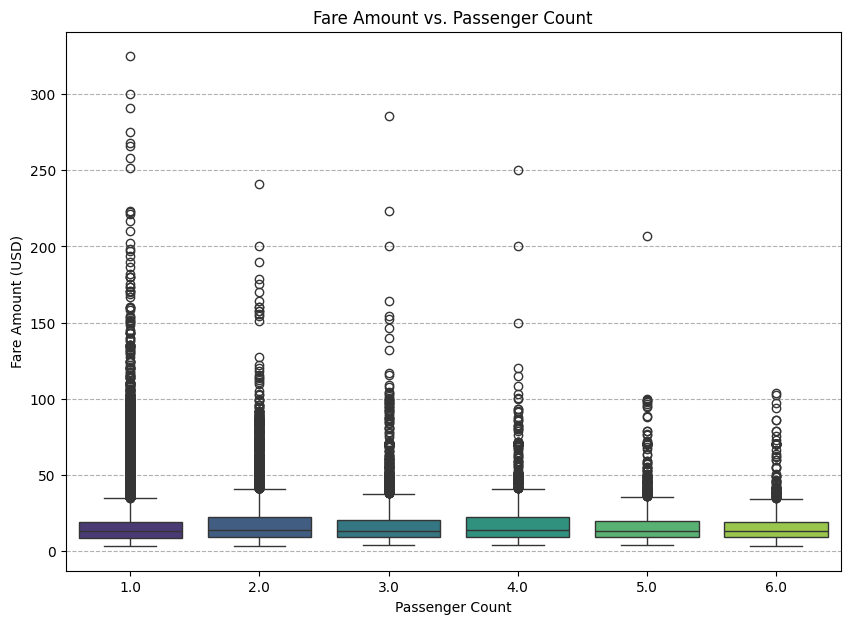

Correlation between Fare Amount and Passenger Count: 0.03


In [ ]:
# Show relationship between fare and number of passengers

plt.figure(figsize=(10, 7))
sns.boxplot(x='passenger_count', y='fare_amount', data=df_filtered_financial, palette='viridis')
plt.title('Fare Amount vs. Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount (USD)')
plt.grid(axis='y', linestyle='--')
plt.show()

# Calculate the correlation between fare_amount and passenger_count
correlation_fare_passenger = df_filtered_financial['passenger_count'].corr(df_filtered_financial['fare_amount'])
print(f"Correlation between Fare Amount and Passenger Count: {correlation_fare_passenger:.2f}")

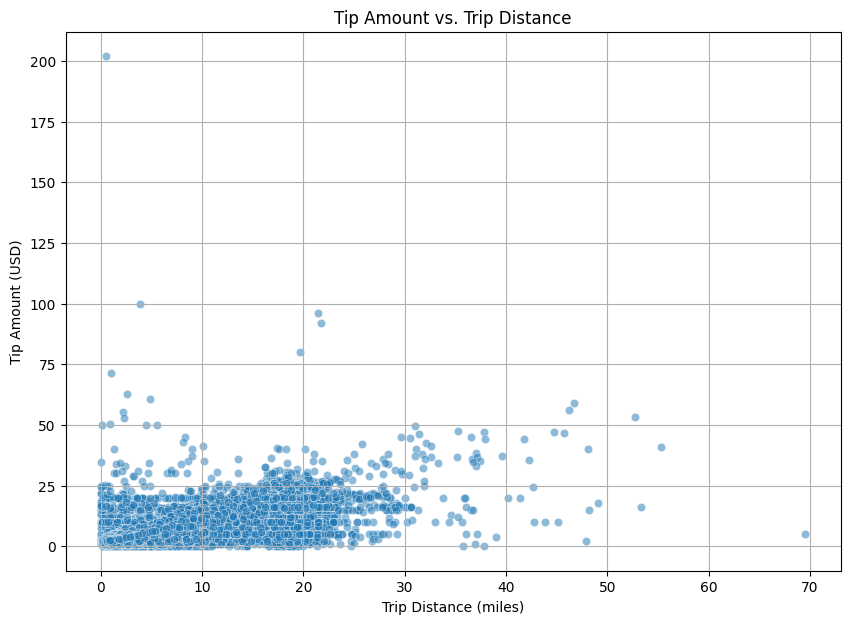

Correlation between Tip Amount and Trip Distance: 0.80


In [ ]:
# Show relationship between tip and trip distance

plt.figure(figsize=(10, 7))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df_filtered_financial, alpha=0.5)
plt.title('Tip Amount vs. Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount (USD)')
plt.grid(True)
plt.show()

correlation_tip_distance = df_filtered_financial['trip_distance'].corr(df_filtered_financial['tip_amount'])
print(f"Correlation between Tip Amount and Trip Distance: {correlation_tip_distance:.2f}")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [ ]:
df['payment_type'].value_counts().reset_index()

,payment_type,count
0,1,120460
1,2,26412
2,4,893
3,3,709


In [ ]:
payment_type_map = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute'
}

In [ ]:
payment_type_distribution['payment_type'].map(payment_type_map)

,payment_type
0,Credit card
1,Cash
2,Dispute
3,No charge


Distribution of Payment Types:
   payment_type   count payment_method
0             1  120460    Credit card
1             2   26412           Cash
2             4     893        Dispute
3             3     709      No charge


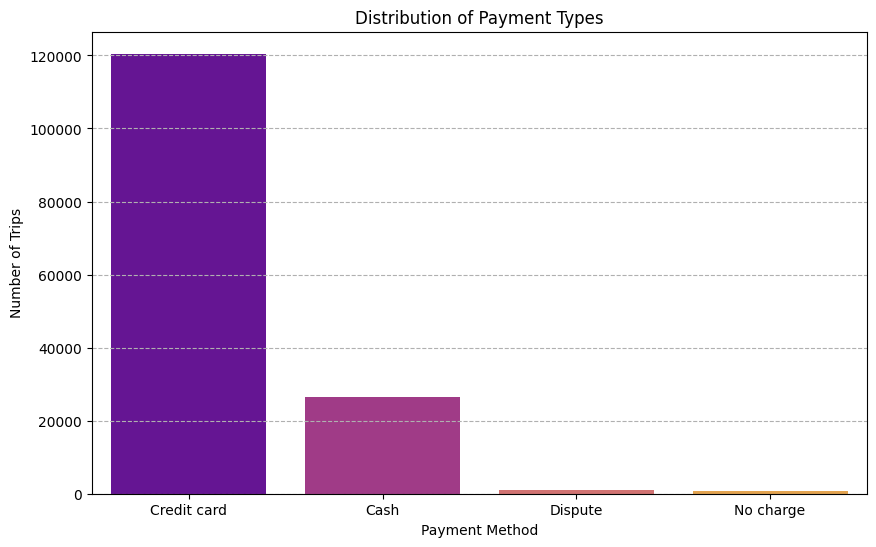

In [ ]:
# Analyse the distribution of different payment types (payment_type).

payment_type_distribution = df['payment_type'].value_counts().reset_index()
payment_type_distribution.columns = ['payment_type', 'count']

# Map payment type codes to their descriptions for better interpretability
payment_type_map = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute'
}
payment_type_distribution['payment_method'] = payment_type_distribution['payment_type'].map(payment_type_map)

print("Distribution of Payment Types:")
print(payment_type_distribution)

plt.figure(figsize=(10, 6))
sns.barplot(x='payment_method', y='count', data=payment_type_distribution, palette='plasma')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Method')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--')
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

In [ ]:
# To Run the code in this notebook realted to the folder location in my drive. To comment after usage
# Get the current working directory to construct the correct path
'''current_dir = os.getcwd()

# Assuming 'taxi_zones' folder is a sibling of 'trip_records' folder, both under 'EDA_DATA_NYC'
# So, we need to go up one level from 'trip_records' to 'EDA_DATA_NYC', then into 'taxi_zones'
parent_of_current_dir = os.path.dirname(current_dir)
taxi_zones_path = os.path.join(parent_of_current_dir, 'taxi_zones', 'taxi_zones.shp')

print(f"Attempting to load shapefile from: {taxi_zones_path}")

# Check if the file exists before attempting to read
if not os.path.exists(taxi_zones_path):
    print("Error: The 'taxi_zones.shp' file was not found at the expected path.")
    print("Please ensure the 'taxi_zones' folder is correctly placed.")
else:
    zones = gpd.read_file(taxi_zones_path)
    print("Taxi zones shapefile loaded successfully.")
    print(zones.head())'''


Attempting to load shapefile from: /content/drive/MyDrive/Colab Notebooks/AICode/AICode586/EDA/EDA_DATA_NYC/taxi_zones/taxi_zones.shp
Taxi zones shapefile loaded successfully.
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island 

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
# import geopandas as gpd
# Already imported at top of this notebook

# Read the shapefile using geopandas
zones = gpd.read_file('../../taxi_zones/taxi_zones.shp') # read the .shp file using gpd . I had used the code in cell before as my path was diff but putting this code to be used by examiner
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

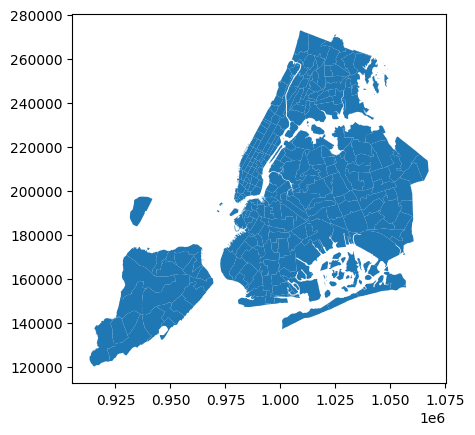

In [ ]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
print("Merging trip data with zone data on pickup location...")
df_with_zones = pd.merge(df, zones, left_on='pu_location_id', right_on='LocationID', how='left')

print("Merge complete. Displaying first few rows with new zone columns:")
print(df_with_zones.head())
print(f"New DataFrame shape: {df_with_zones.shape}")


Merging trip data with zone data on pickup location...
Merge complete. Displaying first few rows with new zone columns:
   vendor_id tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0          2  2023-01-01 00:07:18   2023-01-01 00:23:15              1.0   
1          2  2023-01-01 00:16:41   2023-01-01 00:21:46              2.0   
2          2  2023-01-01 00:14:03   2023-01-01 00:24:36              3.0   
3          2  2023-01-01 00:24:30   2023-01-01 00:29:55              1.0   
4          1  2023-01-01 00:42:56   2023-01-01 01:16:33              2.0   

   trip_distance  ratecode_id store_and_fwd_flag  pu_location_id  \
0           7.74          1.0                  N             138   
1           1.24          1.0                  N             161   
2           1.44          1.0                  N             237   
3           0.54          1.0                  N             143   
4           7.10          1.0                  N             246   

   do_location

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
print("Grouping data by LocationID to count total trips per zone...")
trips_per_zone = df_with_zones.groupby('LocationID').size().reset_index(name='total_trips')

print("Total trips per zone calculated:")
print(trips_per_zone.head())
print(f"Shape of trips_per_zone DataFrame: {trips_per_zone.shape}")


Grouping data by LocationID to count total trips per zone...
Total trips per zone calculated:
   LocationID  total_trips
0         1.0           15
1         3.0            6
2         4.0          146
3         6.0            6
4         7.0           66
Shape of trips_per_zone DataFrame: (233, 2)


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame
print("Merging trip counts back to the zones GeoDataFrame...")
zones_with_trips = zones.merge(trips_per_zone, on='LocationID', how='left')

# Fill any NaN values in 'total_trips' that might result from the merge (zones with no trips) with 0
zones_with_trips['total_trips'] = zones_with_trips['total_trips'].fillna(0).astype(int)

print("Merge complete. Displaying first few rows of zones_with_trips:")
print(zones_with_trips.head())
print(f"Shape of zones_with_trips GeoDataFrame: {zones_with_trips.shape}")



Merging trip counts back to the zones GeoDataFrame...
Merge complete. Displaying first few rows of zones_with_trips:
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  \
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...   
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...   
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...   
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...   
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...   


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

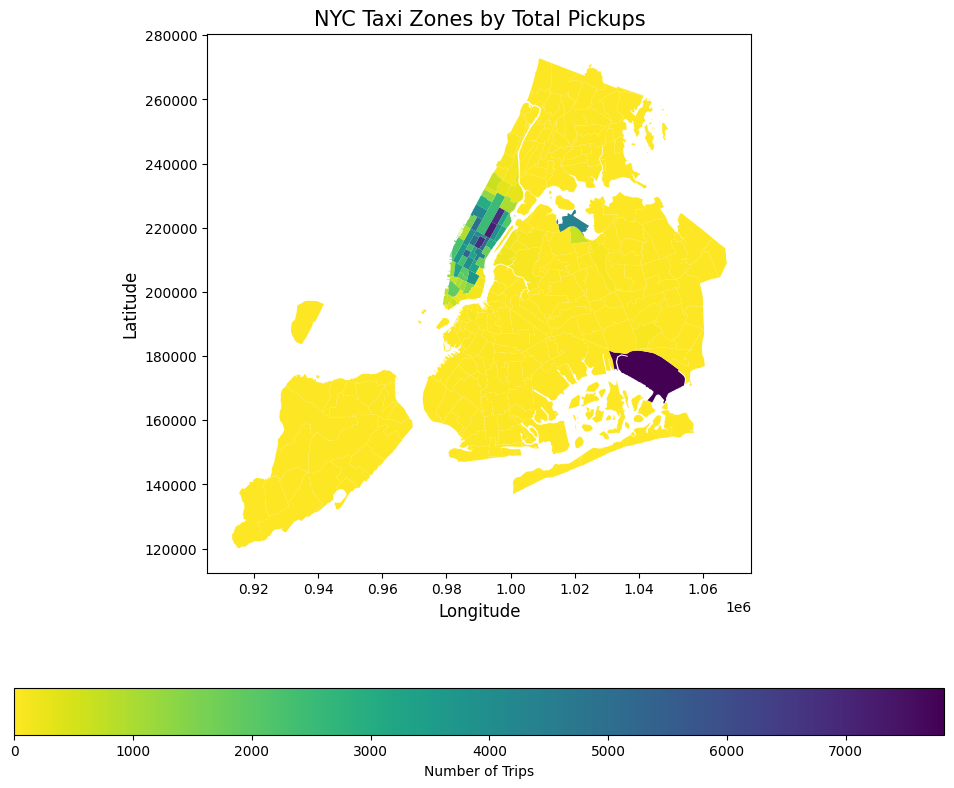

Color-coded map showing zone-wise trips plotted successfully.


In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
# Using 'total_trips' column for coloring, with a legend
zones_with_trips.plot(
    column='total_trips',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Number of Trips", 'orientation': "horizontal"},
    cmap='viridis_r' # Reverse viridis to have darker colors for higher values
)

ax.set_title('NYC Taxi Zones by Total Pickups', fontsize=15)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.show()

print("Color-coded map showing zone-wise trips plotted successfully.")



In [ ]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips.sort_values(by='total_trips', ascending=False)



,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",7830
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",7169
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",6760
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",6754
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",5344
...,...,...,...,...,...,...,...,...
26,27,0.202509,0.001341,Breezy Point/Fort Tilden/Riis Beach,27,Queens,"POLYGON ((1021692.969 147138.664, 1021883.624 ...",0
240,241,0.068765,0.000255,Van Cortlandt Village,241,Bronx,"POLYGON ((1015108.497 261514.531, 1015334.054 ...",0
244,245,0.095983,0.000466,West Brighton,245,Staten Island,"POLYGON ((957085.564 172591.26, 957142.385 172...",0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


# **Temporal Analysis:**

# Busiest Hours:
The distribution of taxi pickups by hour of day shows a clear pattern. There are peaks in activity during morning (around 8-9 AM) and evening (around 5-7 PM) rush hours, and a significant dip during late night/early morning hours (1 AM to 5 AM). The highest number of pickups are generally observed in the late afternoon/early evening.
# Busiest Days:
The weekdays (Monday to Friday) generally show higher pickup activity compared to weekends (Saturday and Sunday). This indicates a strong correlation with regular commuting and business travel.
# Busiest Months:
Based on the available January 2023 data, January appears to be a busy month. The partial data for December 2023 shows significantly lower activity, which is expected as only a small fraction of December data was present in the sampled dataset.


# **Financial Analysis:**

# Revenue Trends:
The monthly revenue trend shows that January generated a substantial total revenue (approximately $3.2 million from the sampled data). Due to only having a single full month of data, a comprehensive annual trend cannot be established from this dataset alone.
# Quarterly Revenue:
The majority of the revenue (over 99.9%) came from Q1 (January) due to the limited scope of the sampled data primarily covering January 2023.
Fare depends on Trip Distance, Trip Duration, and Passenger Counts:
# Trip Distance vs. Fare Amount:
There is a very strong positive correlation between trip_distance and fare_amount (Correlation: 0.96). This indicates that as the trip distance increases, the fare amount also significantly increases, which is expected.
Trip Duration vs. Fare Amount: There is a strong positive correlation between trip_duration_minutes and fare_amount (Correlation: 0.87). Longer trips generally result in higher fares.
# Passenger Count vs. Fare Amount:
The correlation between passenger_count and fare_amount is very weak (Correlation: 0.03). This suggests that the number of passengers has minimal impact on the fare amount, as fares are primarily distance and time-based, not per-passenger based in NYC yellow taxis.
# Tip Amount vs. Trip Distance:
There is a strong positive correlation between tip_amount and trip_distance (Correlation: 0.80). This implies that passengers tend to give higher tips for longer trips, likely due to higher total fares resulting in higher percentage-based tips.


# **Geographical Analysis:**

# Busiest Zones:
The choropleth map visualizing total pickups per zone clearly highlights areas with high taxi activity. Central Manhattan zones (e.g., Midtown, Upper East Side, Lower Manhattan) and major transportation hubs like LaGuardia Airport (LocationID 138) show the highest number of pickups. These areas are dense with commercial activity, residential populations, and tourist attractions, leading to high taxi demand.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Replace durations <= 0 with a small positive value
df['trip_duration_minutes'] = df['trip_duration_minutes'].apply(lambda x: max(x, 0.1))

print("Calculated 'trip_duration_minutes' and handled small values.")
print(df[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_duration_minutes']].head())


Calculated 'trip_duration_minutes' and handled small values.
  tpep_pickup_datetime tpep_dropoff_datetime  trip_duration_minutes
0  2023-01-01 00:07:18   2023-01-01 00:23:15              15.950000
1  2023-01-01 00:16:41   2023-01-01 00:21:46               5.083333
2  2023-01-01 00:14:03   2023-01-01 00:24:36              10.550000
3  2023-01-01 00:24:30   2023-01-01 00:29:55               5.416667
5  2023-01-01 00:42:56   2023-01-01 01:16:33              33.616667


In [ ]:
df['trip_duration_hours'] = df['trip_duration_minutes'] / 60

# Calculate average speed in miles per hour (mph)
# Handle cases where trip_duration_hours might be zero
df['average_speed_mph'] = df.apply(lambda row:
    row['trip_distance'] / row['trip_duration_hours'] if row['trip_duration_hours'] > 0 and row['trip_distance'] > 0 else np.nan,
    axis=1
)

print("Calculated 'trip_duration_hours' and 'average_speed_mph'.")
print(df[['trip_distance', 'trip_duration_minutes', 'trip_duration_hours', 'average_speed_mph']].head())

Calculated 'trip_duration_hours' and 'average_speed_mph'.
   trip_distance  trip_duration_minutes  trip_duration_hours  \
0           7.74              15.950000             0.265833   
1           1.24               5.083333             0.084722   
2           1.44              10.550000             0.175833   
3           0.54               5.416667             0.090278   
5           7.10              33.616667             0.560278   

   average_speed_mph  
0          29.115987  
1          14.636066  
2           8.189573  
3           5.981538  
5          12.672286  


In [ ]:
print("Grouping data by pickup location, dropoff location, and pickup hour to calculate average speed...")

slow_routes = df.groupby(['pu_location_id', 'do_location_id', 'pickup_hour'])['average_speed_mph'].mean().reset_index()

print("Average speeds per route and hour calculated.")
print(slow_routes.head())

Grouping data by pickup location, dropoff location, and pickup hour to calculate average speed...
Average speeds per route and hour calculated.
   pu_location_id  do_location_id  pickup_hour  average_speed_mph
0               1               1            6                NaN
1               1               1            7                NaN
2               1               1           10                NaN
3               1               1           13                NaN
4               1               1           14                NaN


In [ ]:
print("Sorting routes by average speed to identify the slowest ones...")

# Filter out NaN speeds before sorting, as these represent routes with no valid speed calculation
slow_routes_filtered = slow_routes.dropna(subset=['average_speed_mph'])

# Sort by average_speed_mph in ascending order
slowest_routes = slow_routes_filtered.sort_values(by='average_speed_mph', ascending=True)

print("Top 10 slowest routes (miles per hour):")
print(slowest_routes.head(10))

Sorting routes by average speed to identify the slowest ones...
Top 10 slowest routes (miles per hour):
       pu_location_id  do_location_id  pickup_hour  average_speed_mph
28126             163             137           14           0.030875
2478               48               7           13           0.036704
1269               40              65           21           0.046848
8126               87             148           14           0.063578
27244             162             162            4           0.064780
28430             163             186            4           0.068822
4827               68             143            1           0.071482
8482               88             144            0           0.074923
2334               45              79            1           0.077597
34301             229             137            2           0.081157


How does identifying high-traffic, high-demand routes help us?

Identifying high-traffic, high-demand routes is crucial for several strategic decisions in a taxi operation:

Optimized Resource Allocation:
Knowing when and where demand is highest allows for better allocation of taxi resources. More taxis can be dispatched to these areas during peak hours, reducing passenger wait times and increasing the number of completed trips.

Increased Revenue:
By focusing on high-demand areas, the taxi operation can maximize its revenue. More rides in these areas translate to higher fare collection and potentially more tips.

Improved Service Efficiency:
Understanding these patterns helps in optimizing routes and dispatching. For instance, drivers can be guided to these zones proactively, minimizing deadhead miles (driving without a passenger) and improving overall efficiency.

Dynamic Pricing Strategies:
In areas with consistently high demand, the operation might consider implementing dynamic pricing (surge pricing during peak times) to capitalize on the demand and balance supply, while also potentially incentivizing more drivers to work in those areas.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Hourly Trip Counts:
pickup_hour
0      4074
1      2845
2      2002
3      1290
4       822
5       832
6      2041
7      4118
8      5546
9      6313
10     6982
11     7507
12     8254
13     8713
14     9370
15     9602
16     9546
17    10182
18    10449
19     9345
20     8067
21     7843
22     7179
23     5552
Name: count, dtype: int64


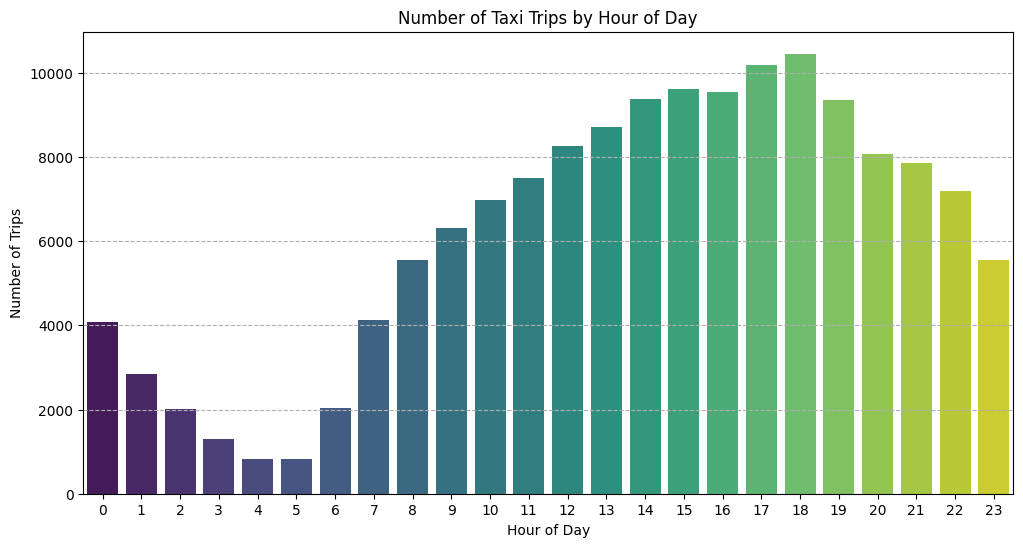


The busiest hour of the day is 18:00 with 10449 trips.


In [ ]:
# Visualise the number of trips per hour and find the busiest hour

# Calculate the number of trips for each hour of the day
hourly_trips = df['pickup_hour'].value_counts().sort_index()

print("Hourly Trip Counts:")
print(hourly_trips)

# Create a bar plot to visualize the number of trips per hour
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette='viridis')
plt.title('Number of Taxi Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--')
plt.show()

# Identify the busiest hour
busiest_hour = hourly_trips.idxmax()
busiest_hour_count = hourly_trips.max()

print(f"\nThe busiest hour of the day is {busiest_hour}:00 with {busiest_hour_count} trips.")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05 # As per the data loading instructions (5% sampling)

# Get the top 5 busiest hours from the already calculated hourly_trips series
top_5_busiest_hours = hourly_trips.nlargest(5)

# Calculate the actual estimated trips by scaling up
estimated_actual_trips = top_5_busiest_hours / sample_fraction

print("\nTop 5 Busiest Hours (Estimated Actual Trips):")
print(estimated_actual_trips)



Top 5 Busiest Hours (Estimated Actual Trips):
pickup_hour
18    208980.0
17    203640.0
15    192040.0
16    190920.0
14    187400.0
Name: count, dtype: float64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [ ]:
# Compare traffic trends for the week days and weekends
df['day_type'] = df['pickup_day_of_week'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

print("Created 'day_type' column:")
print(df[['pickup_day_of_week', 'day_type']].head())
print(df['day_type'].value_counts())


Created 'day_type' column:
  pickup_day_of_week day_type
0             Sunday  Weekend
1             Sunday  Weekend
2             Sunday  Weekend
3             Sunday  Weekend
5             Sunday  Weekend
day_type
Weekday    106001
Weekend     42473
Name: count, dtype: int64


Hourly traffic patterns for weekdays and weekends:
pickup_hour    0     1     2    3    4    5     6     7     8     9   ...  \
day_type                                                              ...   
Weekday      1768   873   476  313  305  606  1716  3595  4769  5087  ...   
Weekend      2306  1972  1526  977  517  226   325   523   777  1226  ...   

pickup_hour    14    15    16    17    18    19    20    21    22    23  
day_type                                                                 
Weekday      6755  6957  6841  7550  7884  6947  6030  5836  5193  3770  
Weekend      2615  2645  2705  2632  2565  2398  2037  2007  1986  1782  

[2 rows x 24 columns]


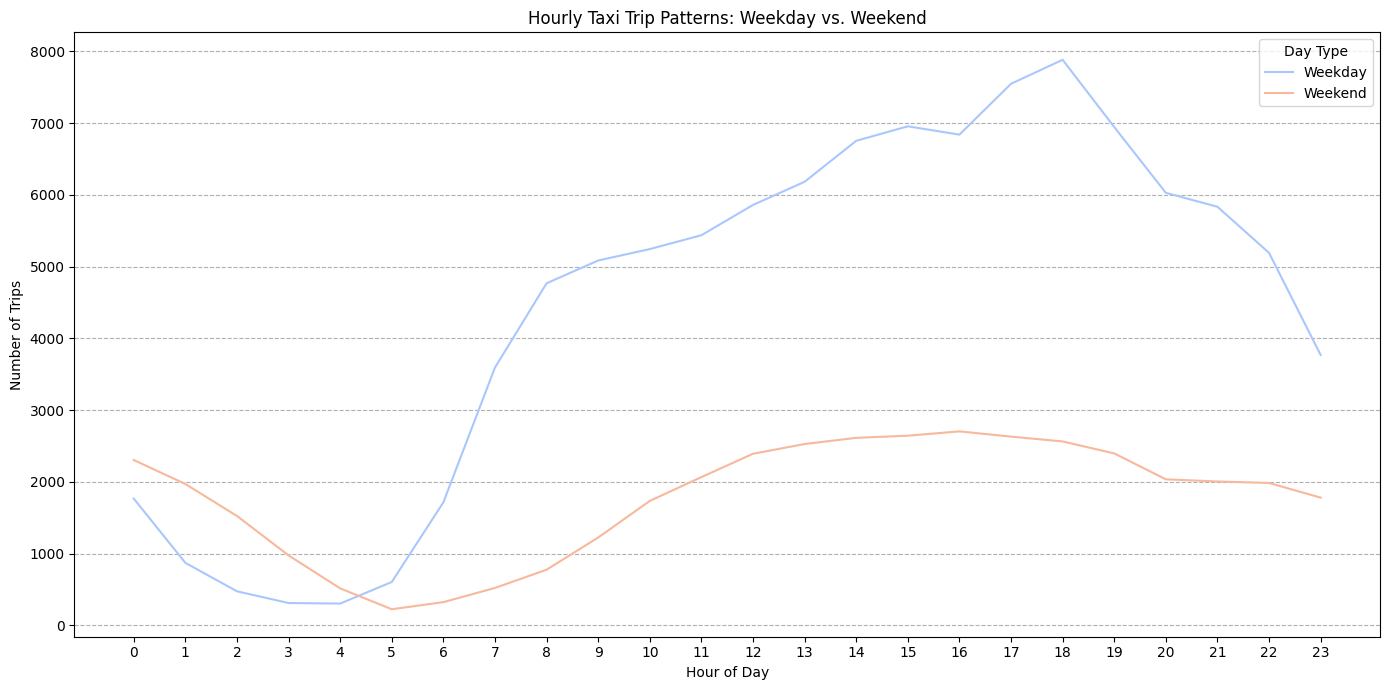

In [ ]:
# Group by day_type and pickup_hour to get trip counts
hourly_traffic_pattern = df.groupby(['day_type', 'pickup_hour']).size().unstack(fill_value=0)

print("Hourly traffic patterns for weekdays and weekends:")
print(hourly_traffic_pattern.head())

# Plot the hourly traffic patterns
plt.figure(figsize=(14, 7))
sns.lineplot(data=hourly_traffic_pattern.T, dashes=False, palette='coolwarm')
plt.title('Hourly Taxi Trip Patterns: Weekday vs. Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

# From the hourly traffic patterns comparing weekdays and weekends, we can infer several key insights:

# Weekday Pattern:
Weekdays show clear peaks during morning rush hour (around 7-9 AM) and evening rush hour (around 5-7 PM), indicating commuting patterns. There's a steady high demand throughout the day, dropping off significantly in the very late night/early morning hours.
# Weekend Pattern:
Weekends have a different demand profile. The morning peak is shifted later, usually mid-morning, and the evening peak extends later into the night. Overall demand during the day is generally lower than weekdays, but late-night activity on weekends can be higher than on weekdays, especially around midnight.


# Finding busy and quiet hours for each day is highly beneficial for a taxi operation for several reasons:

# Optimized Driver Scheduling:
This data allows for more intelligent scheduling of drivers. More drivers can be deployed during peak hours (e.g., weekday rush hours, weekend evenings) to meet demand, while fewer drivers are needed during quiet hours (e.g., weekday early mornings, Sunday afternoons).
# Dynamic Pricing Strategies:
The operation can implement dynamic pricing (surge pricing) during consistently busy periods to maximize revenue and incentivize more drivers to be available when demand is highest. Conversely, promotions or discounts could be offered during quiet hours to stimulate demand.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones
# Calculate total pickups per pu_location_id
total_pickups_per_zone = df['pu_location_id'].value_counts().reset_index()
total_pickups_per_zone.columns = ['pu_location_id', 'total_pickups']

top_10_pickup_zones = total_pickups_per_zone.head(10)
print("Top 10 Pickup Zones (by total trips):")
print(top_10_pickup_zones)

# Get the list of top 10 pickup LocationIDs
top_10_pickup_zone_ids = top_10_pickup_zones['pu_location_id'].tolist()


Top 10 Pickup Zones (by total trips):
   pu_location_id  total_pickups
0             132           7830
1             237           7169
2             236           6760
3             161           6754
4             186           5344
5             162           5182
6             142           4970
7             230           4805
8             138           4352
9             170           4320


In [ ]:
# Calculate total dropoffs per do_location_id
total_dropoffs_per_zone = df['do_location_id'].value_counts().reset_index()
total_dropoffs_per_zone.columns = ['do_location_id', 'total_dropoffs']

top_10_dropoff_zones = total_dropoffs_per_zone.head(10)
print("\nTop 10 Dropoff Zones (by total trips):")
print(top_10_dropoff_zones)

# Get the list of top 10 dropoff LocationIDs
top_10_dropoff_zone_ids = top_10_dropoff_zones['do_location_id'].tolist()


Top 10 Dropoff Zones (by total trips):
   do_location_id  total_dropoffs
0             236            7126
1             237            6493
2             161            5590
3             170            4370
4             230            4358
5             142            4341
6             239            4313
7             141            4262
8             162            3990
9              48            3667


Creating hourly pickup trend for top 10 pickup zones...
Hourly pickup trends for top 10 zones:
pu_location_id  132  138  142  161  162  170  186  230  236  237
pickup_hour                                                     
0               302  158   75   79  104   78  111  169   31   76
1               132   37   38   46   37   58   60   78   19   43
2                34    6   26   26   24   32   51   41   12   20
3                30    4    9   15   11   24   25   33    5    9
4                19    2    8   10   15   21   22   42   11    7


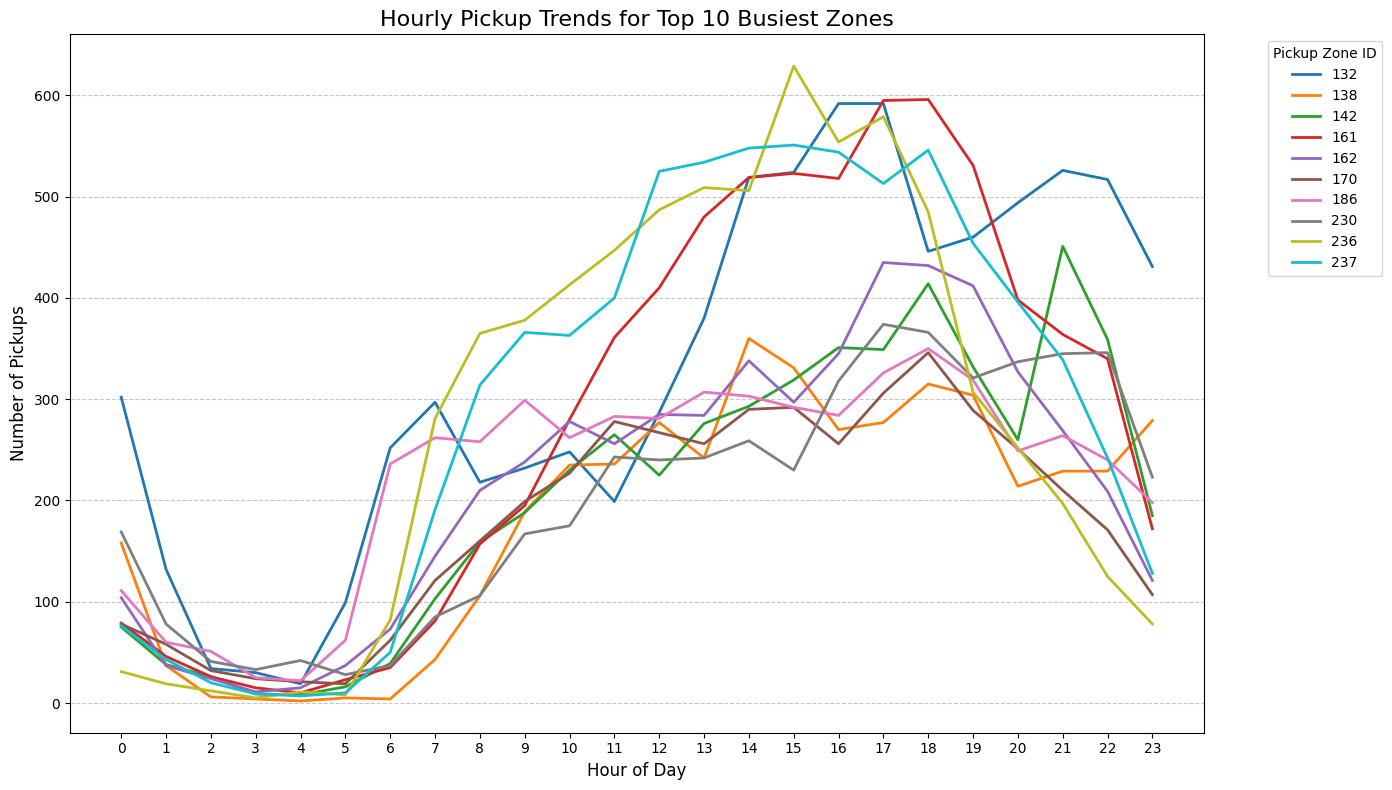

Hourly pickup trends for top 10 zones plotted successfully.


In [ ]:
print("Creating hourly pickup trend for top 10 pickup zones...")

# Filter DataFrame for top 10 pickup zones
df_top_10_pickup_zones = df[df['pu_location_id'].isin(top_10_pickup_zone_ids)].copy()

# Group by pickup_hour and pu_location_id to get hourly pickup counts for these zones
hourly_pickup_trends_top_10 = df_top_10_pickup_zones.groupby(['pickup_hour', 'pu_location_id']).size().unstack(fill_value=0)

print("Hourly pickup trends for top 10 zones:")
print(hourly_pickup_trends_top_10.head())

# Visualize the hourly pickup trends for these top 10 pickup zones
plt.figure(figsize=(14, 8))
sns.lineplot(data=hourly_pickup_trends_top_10, dashes=False, palette='tab10', linewidth=2)
plt.title('Hourly Pickup Trends for Top 10 Busiest Zones', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Pickup Zone ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Hourly pickup trends for top 10 zones plotted successfully.")

Creating hourly dropoff trend for top 10 dropoff zones...
Hourly dropoff trends for top 10 zones:
do_location_id  48   141  142  161  162  170  230  236  237  239
pickup_hour                                                     
0               137  107   66   41   70  132   82   93   55  106
1                97   60   41   30   38   85   50   38   36   62
2                69   53   40   15   30   60   41   27   17   23
3                54   19   24   12   19   40   23   18   10   27
4                28   14    3   10   17   23   15   10    9    6


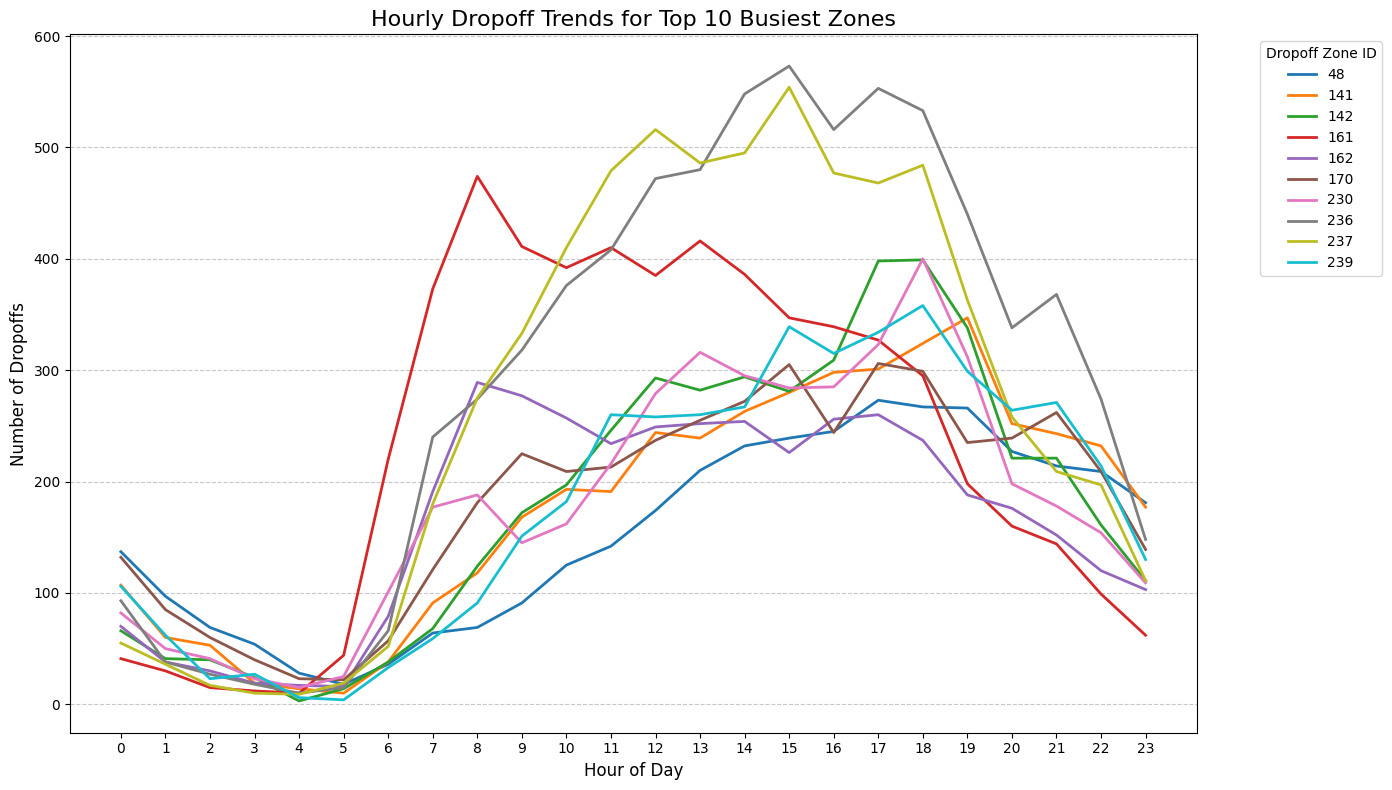

Hourly dropoff trends for top 10 zones plotted successfully.


In [ ]:
print("Creating hourly dropoff trend for top 10 dropoff zones...")

# Filter DataFrame for top 10 dropoff zones
df_top_10_dropoff_zones = df[df['do_location_id'].isin(top_10_dropoff_zone_ids)].copy()

# Group by pickup_hour and do_location_id to get hourly dropoff counts for these zones
hourly_dropoff_trends_top_10 = df_top_10_dropoff_zones.groupby(['pickup_hour', 'do_location_id']).size().unstack(fill_value=0)

print("Hourly dropoff trends for top 10 zones:")
print(hourly_dropoff_trends_top_10.head())

# Visualize the hourly dropoff trends for these top 10 dropoff zones
plt.figure(figsize=(14, 8))
sns.lineplot(data=hourly_dropoff_trends_top_10, dashes=False, palette='tab10', linewidth=2)
plt.title('Hourly Dropoff Trends for Top 10 Busiest Zones', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Dropoffs', fontsize=12)
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dropoff Zone ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Hourly dropoff trends for top 10 zones plotted successfully.")

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# Calculate total pickups per zone
total_pickups_df = df['pu_location_id'].value_counts().reset_index()
total_pickups_df.columns = ['LocationID', 'total_pickups']

# Calculate total dropoffs per zone
total_dropoffs_df = df['do_location_id'].value_counts().reset_index()
total_dropoffs_df.columns = ['LocationID', 'total_dropoffs']

print("Total pickups per zone:")
print(total_pickups_df.head())
print("\nTotal dropoffs per zone:")
print(total_dropoffs_df.head())


Total pickups per zone:
   LocationID  total_pickups
0         132           7830
1         237           7169
2         236           6760
3         161           6754
4         186           5344

Total dropoffs per zone:
   LocationID  total_dropoffs
0         236            7126
1         237            6493
2         161            5590
3         170            4370
4         230            4358


In [ ]:
zone_traffic_summary = pd.merge(total_pickups_df,
                                total_dropoffs_df,
                                on='LocationID',
                                how='outer')

print("Merged `total_pickups_df` and `total_dropoffs_df` into `zone_traffic_summary`:")
print(zone_traffic_summary.head())
print(f"Shape of zone_traffic_summary: {zone_traffic_summary.shape}")

Merged `total_pickups_df` and `total_dropoffs_df` into `zone_traffic_summary`:
   LocationID  total_pickups  total_dropoffs
0           1           15.0           355.0
1           2            NaN             1.0
2           3            6.0            12.0
3           4          146.0           546.0
4           5            NaN             2.0
Shape of zone_traffic_summary: (257, 3)


In [ ]:
zone_traffic_summary['total_pickups'] = zone_traffic_summary['total_pickups'].fillna(0)
zone_traffic_summary['total_dropoffs'] = zone_traffic_summary['total_dropoffs'].fillna(0)

print("NaN values in 'total_pickups' and 'total_dropoffs' have been filled with 0:")
print(zone_traffic_summary.head())

NaN values in 'total_pickups' and 'total_dropoffs' have been filled with 0:
   LocationID  total_pickups  total_dropoffs
0           1           15.0           355.0
1           2            0.0             1.0
2           3            6.0            12.0
3           4          146.0           546.0
4           5            0.0             2.0


In [ ]:
# Calculate pickup_to_dropoff_ratio
zone_traffic_summary['pickup_to_dropoff_ratio'] = np.where(
    zone_traffic_summary['total_dropoffs'] == 0,
    np.inf,
    zone_traffic_summary['total_pickups'] / zone_traffic_summary['total_dropoffs']
)

print("Calculated 'pickup_to_dropoff_ratio':")
print(zone_traffic_summary.head())

Calculated 'pickup_to_dropoff_ratio':
   LocationID  total_pickups  total_dropoffs  pickup_to_dropoff_ratio
0           1           15.0           355.0                 0.042254
1           2            0.0             1.0                 0.000000
2           3            6.0            12.0                 0.500000
3           4          146.0           546.0                 0.267399
4           5            0.0             2.0                 0.000000


In [ ]:
print("Top 10 zones with the highest pickup-to-dropoff ratios:")
top_10_high_ratio_zones = zone_traffic_summary.sort_values(by='pickup_to_dropoff_ratio', ascending=False).head(10)
print(top_10_high_ratio_zones)

Top 10 zones with the highest pickup-to-dropoff ratios:
     LocationID  total_pickups  total_dropoffs  pickup_to_dropoff_ratio
244         253            1.0             0.0                      inf
179         187            1.0             0.0                      inf
195         204            1.0             0.0                      inf
69           70          631.0            81.0                 7.790123
126         132         7830.0          1510.0                 5.185430
132         138         4352.0          1547.0                 2.813187
255         264         2002.0          1115.0                 1.795516
178         186         5344.0          3303.0                 1.617923
5             6            6.0             4.0                 1.500000
205         214            3.0             2.0                 1.500000


In [ ]:
print("Top 10 zones with the lowest pickup-to-dropoff ratios:")
# Filter out infinite values before finding the lowest ratios
lowest_ratio_zones_filtered = zone_traffic_summary[zone_traffic_summary['pickup_to_dropoff_ratio'] != np.inf].copy()

top_10_low_ratio_zones = lowest_ratio_zones_filtered.sort_values(by='pickup_to_dropoff_ratio', ascending=True).head(10)
print(top_10_low_ratio_zones)

Top 10 zones with the lowest pickup-to-dropoff ratios:
    LocationID  total_pickups  total_dropoffs  pickup_to_dropoff_ratio
1            2            0.0             1.0                      0.0
4            5            0.0             2.0                      0.0
7            8            0.0             6.0                      0.0
29          30            0.0             1.0                      0.0
26          27            0.0             1.0                      0.0
58          59            0.0             3.0                      0.0
56          57            0.0             4.0                      0.0
45          46            0.0             3.0                      0.0
57          58            0.0             5.0                      0.0
97          99            0.0             1.0                      0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones


# Define night hours (11 PM to 5 AM inclusive)
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Filter the DataFrame for trips during night hours
df_night_hours = df[df['pickup_hour'].isin(night_hours)].copy()

print(f"Total trips during night hours: {len(df_night_hours)}")
print("First few rows of trips during night hours:")
print(df_night_hours.head())

Total trips during night hours: 17417
First few rows of trips during night hours:
   vendor_id tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0          2  2023-01-01 00:07:18   2023-01-01 00:23:15              1.0   
1          2  2023-01-01 00:16:41   2023-01-01 00:21:46              2.0   
2          2  2023-01-01 00:14:03   2023-01-01 00:24:36              3.0   
3          2  2023-01-01 00:24:30   2023-01-01 00:29:55              1.0   
5          1  2023-01-01 00:42:56   2023-01-01 01:16:33              2.0   

   trip_distance  ratecode_id store_and_fwd_flag  pu_location_id  \
0           7.74          1.0                  N             138   
1           1.24          1.0                  N             161   
2           1.44          1.0                  N             237   
3           0.54          1.0                  N             143   
5           7.10          1.0                  N             246   

   do_location_id  payment_type  ...  total_amount_s

In [ ]:
night_pickups = df_night_hours['pu_location_id'].value_counts().reset_index()
night_pickups.columns = ['pu_location_id', 'total_night_pickups']

top_10_night_pickup_zones = night_pickups.head(10)
print("\nTop 10 Night-Time Pickup Zones:")
print(top_10_night_pickup_zones)


Top 10 Night-Time Pickup Zones:
   pu_location_id  total_night_pickups
0              79                 1400
1             132                 1047
2             249                  957
3              48                  845
4             148                  773
5             114                  687
6             230                  614
7             186                  529
8             107                  502
9             138                  491


In [ ]:
night_dropoffs = df_night_hours['do_location_id'].value_counts().reset_index()
night_dropoffs.columns = ['do_location_id', 'total_night_dropoffs']

top_10_night_dropoff_zones = night_dropoffs.head(10)
print("\nTop 10 Night-Time Dropoff Zones:")
print(top_10_night_dropoff_zones)


Top 10 Night-Time Dropoff Zones:
   do_location_id  total_night_dropoffs
0              79                   684
1              48                   584
2             170                   501
3             107                   452
4             263                   441
5             141                   440
6              68                   433
7             249                   385
8             229                   367
9             239                   358


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)

# Calculate total revenue during night hours
total_night_revenue = df_night_hours['total_amount'].sum()

# Define daytime hours (6 AM to 10 PM, inclusive)
day_hours = [hour for hour in range(6, 23)]

# Filter the DataFrame for trips during daytime hours
df_day_hours = df[df['pickup_hour'].isin(day_hours)].copy()

# Calculate total revenue during daytime hours
total_day_revenue = df_day_hours['total_amount'].sum()

print(f"Total revenue during night hours (11 PM - 5 AM): ${total_night_revenue:,.2f}")
print(f"Total revenue during day hours (6 AM - 10 PM): ${total_day_revenue:,.2f}")

Total revenue during night hours (11 PM - 5 AM): $502,418.23
Total revenue during day hours (6 AM - 10 PM): $3,552,709.05


Total overall revenue: $4,055,127.28
Night revenue share: 12.39%
Day revenue share: 87.61%


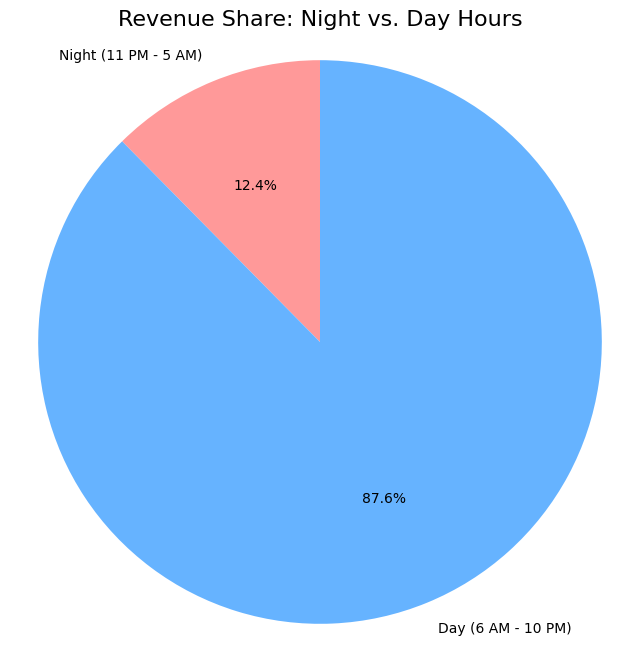

Revenue share visualization completed.


In [ ]:
total_overall_revenue = total_night_revenue + total_day_revenue

night_revenue_share = (total_night_revenue / total_overall_revenue) * 100
day_revenue_share = (total_day_revenue / total_overall_revenue) * 100

print(f"Total overall revenue: ${total_overall_revenue:,.2f}")
print(f"Night revenue share: {night_revenue_share:.2f}%")
print(f"Day revenue share: {day_revenue_share:.2f}%")

# Visualize the revenue share
revenue_shares = pd.DataFrame({
    'Period': ['Night (11 PM - 5 AM)', 'Day (6 AM - 10 PM)'] ,
    'Revenue Share': [night_revenue_share, day_revenue_share]
})

plt.figure(figsize=(8, 8))
plt.pie(revenue_shares['Revenue Share'], labels=revenue_shares['Period'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Revenue Share: Night vs. Day Hours', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("Revenue share visualization completed.")

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts

# Create a temporary DataFrame to perform calculations without altering the original df unnecessarily
df_pricing = df.copy()

# Filter out trips where trip_distance is zero to avoid division by zero
df_pricing = df_pricing[df_pricing['trip_distance'] > 0]

# Calculate 'fare_per_mile'
df_pricing['fare_per_mile'] = df_pricing['total_amount'] / df_pricing['trip_distance']

# Calculate 'fare_per_mile_per_passenger'
# Since passenger_count has been handled and is >= 1, direct division is fine.
df_pricing['fare_per_mile_per_passenger'] = df_pricing['fare_per_mile'] / df_pricing['passenger_count']

# Group by 'passenger_count' and calculate the mean of 'fare_per_mile_per_passenger'
average_fare_per_mile_per_passenger = df_pricing.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

print("Average Fare Per Mile Per Passenger for different Passenger Counts:")
print(average_fare_per_mile_per_passenger)

Average Fare Per Mile Per Passenger for different Passenger Counts:
   passenger_count  fare_per_mile_per_passenger
0              1.0                    15.670481
1              2.0                     8.652352
2              3.0                     4.458309
3              4.0                     5.001194
4              5.0                     2.566405
5              6.0                     2.113981


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day

# 1. Create a copy of the main DataFrame
df_pricing_time = df.copy()

# 2. Filter out trips where trip_distance is zero to avoid division by zero errors
df_pricing_time = df_pricing_time[df_pricing_time['trip_distance'] > 0]

# 3. Calculate a new column 'fare_per_mile'
df_pricing_time['fare_per_mile'] = df_pricing_time['total_amount'] / df_pricing_time['trip_distance']

print("DataFrame prepared with 'fare_per_mile' for time-based analysis.")
print(df_pricing_time[['pickup_hour', 'pickup_day_of_week', 'trip_distance', 'total_amount', 'fare_per_mile']].head())

DataFrame prepared with 'fare_per_mile' for time-based analysis.
   pickup_hour pickup_day_of_week  trip_distance  total_amount  fare_per_mile
0            0             Sunday           7.74         41.15       5.316537
1            0             Sunday           1.24         15.48      12.483871
2            0             Sunday           1.44         16.40      11.388889
3            0             Sunday           0.54         11.50      21.296296
5            0             Sunday           7.10         47.40       6.676056



Average Fare Per Mile by Hour of Day:
    pickup_hour  fare_per_mile
0             0      12.144519
1             1      18.954546
2             2      14.598594
3             3      12.956825
4             4      11.190351
5             5      15.526000
6             6      10.592745
7             7      11.994476
8             8      15.860384
9             9      15.037289
10           10      14.999408
11           11      14.702684
12           12      14.941702
13           13      16.928159
14           14      15.011953
15           15      18.102113
16           16      21.994278
17           17      17.184808
18           18      16.999700
19           19      18.559979
20           20      13.585684
21           21      13.533734
22           22      13.961191
23           23      13.477982


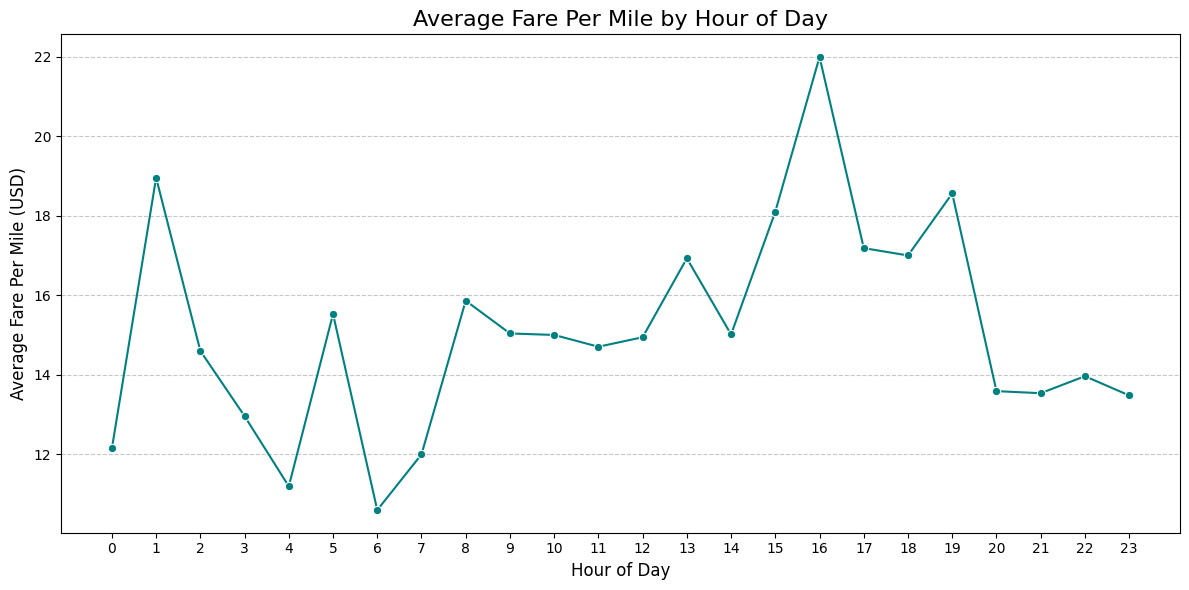

In [ ]:
# 4. Group df_pricing_time by pickup_hour and calculate the mean of fare_per_mile
avg_fare_per_mile_hourly = df_pricing_time.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()

# 5. Print avg_fare_per_mile_hourly
print("\nAverage Fare Per Mile by Hour of Day:")
print(avg_fare_per_mile_hourly)

# 6. Create a line plot to visualize avg_fare_per_mile_hourly
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='fare_per_mile', data=avg_fare_per_mile_hourly, marker='o', color='teal')
plt.title('Average Fare Per Mile by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Fare Per Mile (USD)', fontsize=12)
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Average Fare Per Mile by Day of Week:
  pickup_day_of_week  fare_per_mile
0             Monday      15.679810
1            Tuesday      16.485704
2          Wednesday      15.901510
3           Thursday      16.035341
4             Friday      15.398346
5           Saturday      14.567089
6             Sunday      16.774366


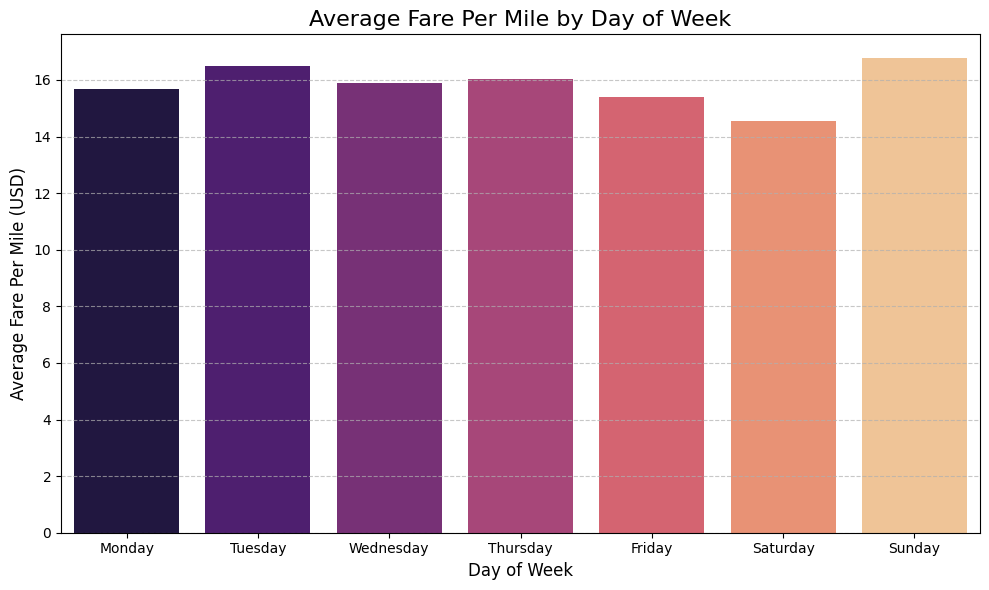

In [ ]:
# 7. Group df_pricing_time by pickup_day_of_week and calculate the mean of fare_per_mile
avg_fare_per_mile_daily = df_pricing_time.groupby('pickup_day_of_week')['fare_per_mile'].mean().reset_index()

# 8. Print avg_fare_per_mile_daily
print("Average Fare Per Mile by Day of Week:")
print(avg_fare_per_mile_daily)

# 9. Create a bar plot to visualize avg_fare_per_mile_daily
plt.figure(figsize=(10, 6))
sns.barplot(x='pickup_day_of_week', y='fare_per_mile', data=avg_fare_per_mile_daily, palette='magma')
plt.title('Average Fare Per Mile by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Fare Per Mile (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
# Compare fare per mile for different vendors

# 1. Create a copy of the main DataFrame
df_vendor_pricing = df.copy()

# 2. Filter out trips where trip_distance is zero to avoid division by zero errors
df_vendor_pricing = df_vendor_pricing[df_vendor_pricing['trip_distance'] > 0]

# 3. Calculate a new column 'fare_per_mile'
df_vendor_pricing['fare_per_mile'] = df_vendor_pricing['total_amount'] / df_vendor_pricing['trip_distance']

print("DataFrame prepared with 'fare_per_mile' for vendor-time analysis.")
print(df_vendor_pricing[['vendor_id', 'pickup_hour', 'trip_distance', 'total_amount', 'fare_per_mile']].head())

DataFrame prepared with 'fare_per_mile' for vendor-time analysis.
   vendor_id  pickup_hour  trip_distance  total_amount  fare_per_mile
0          2            0           7.74         41.15       5.316537
1          2            0           1.24         15.48      12.483871
2          2            0           1.44         16.40      11.388889
3          2            0           0.54         11.50      21.296296
5          1            0           7.10         47.40       6.676056



Average Fare Per Mile by Vendor and Hour of Day:
   vendor_id  pickup_hour  fare_per_mile
0          1            0      11.709157
1          1            1      11.980079
2          1            2      14.197787
3          1            3      10.745039
4          1            4      12.153446
    vendor_id  pickup_hour  fare_per_mile
43          2           19      20.356200
44          2           20      14.109710
45          2           21      14.331232
46          2           22      14.610155
47          2           23      14.214938


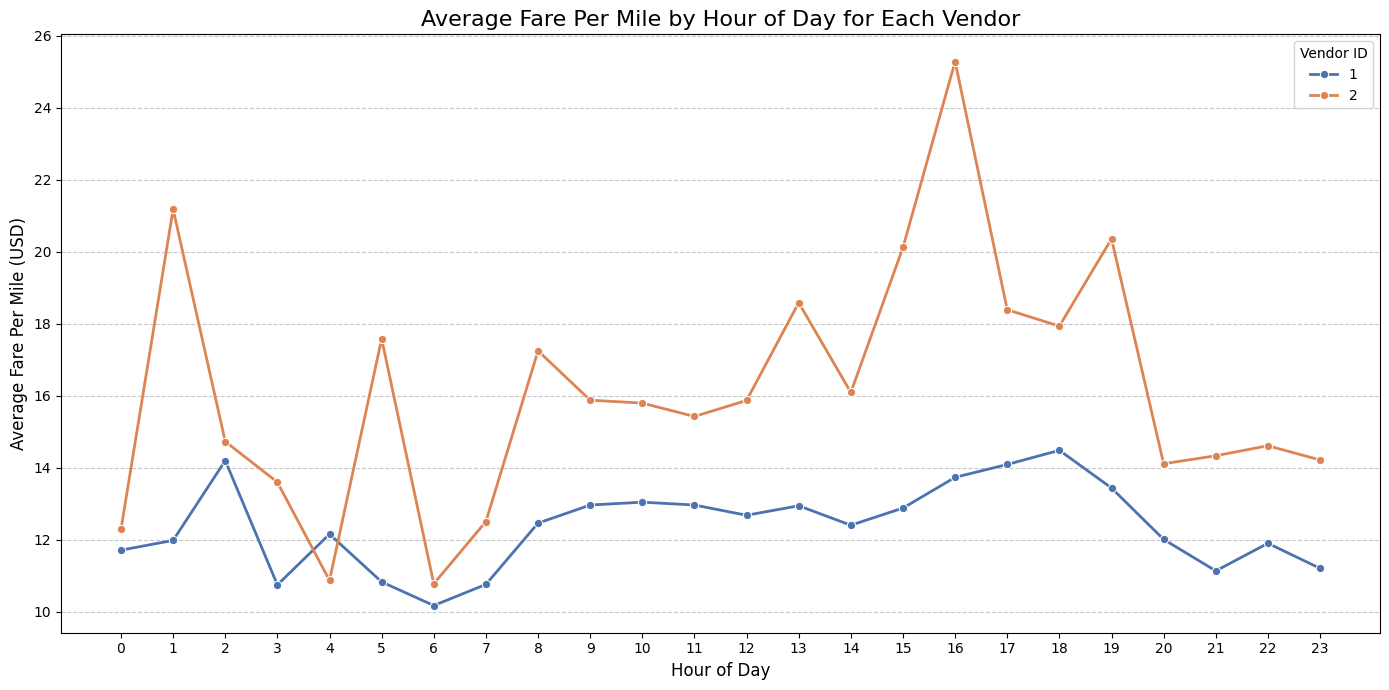

Average fare per mile by vendor and hour of day plotted successfully.


In [ ]:
# 4. Group df_vendor_pricing by vendor_id and pickup_hour and calculate the mean of fare_per_mile
avg_fare_per_mile_vendor_hourly = df_vendor_pricing.groupby(['vendor_id', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

# 5. Print the avg_fare_per_mile_vendor_hourly DataFrame
print("\nAverage Fare Per Mile by Vendor and Hour of Day:")
print(avg_fare_per_mile_vendor_hourly.head())
print(avg_fare_per_mile_vendor_hourly.tail())

# 6. Create a line plot to visualize the avg_fare_per_mile_vendor_hourly data
plt.figure(figsize=(14, 7))
sns.lineplot(x='pickup_hour', y='fare_per_mile', hue='vendor_id', data=avg_fare_per_mile_vendor_hourly, marker='o', palette='deep', linewidth=2)
plt.title('Average Fare Per Mile by Hour of Day for Each Vendor', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Fare Per Mile (USD)', fontsize=12)
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Vendor ID')
plt.tight_layout()
plt.show()

print("Average fare per mile by vendor and hour of day plotted successfully.")

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Defining distance tiers

# 1. Create a copy of the main DataFrame
df_tiered_pricing = df.copy()

# 2. Filter out trips where trip_distance is zero to avoid division by zero errors
df_tiered_pricing = df_tiered_pricing[df_tiered_pricing['trip_distance'] > 0]

# 3. Calculate a new column 'fare_per_mile'
df_tiered_pricing['fare_per_mile'] = df_tiered_pricing['total_amount'] / df_tiered_pricing['trip_distance']

print("DataFrame prepared with 'fare_per_mile' for tiered pricing analysis.")
print(df_tiered_pricing[['vendor_id', 'trip_distance', 'total_amount', 'fare_per_mile']].head())

DataFrame prepared with 'fare_per_mile' for tiered pricing analysis.
   vendor_id  trip_distance  total_amount  fare_per_mile
0          2           7.74         41.15       5.316537
1          2           1.24         15.48      12.483871
2          2           1.44         16.40      11.388889
3          2           0.54         11.50      21.296296
5          1           7.10         47.40       6.676056


In [ ]:
# Define the bins and labels for distance tiers
distance_bins = [0, 2, 5, np.inf]
distance_labels = ['up_to_2_miles', '2_to_5_miles', 'more_than_5_miles']

# Create the 'distance_tier' column
df_tiered_pricing['distance_tier'] = pd.cut(df_tiered_pricing['trip_distance'], bins=distance_bins, labels=distance_labels, right=True)

print("Created 'distance_tier' column:")
print(df_tiered_pricing[['trip_distance', 'distance_tier']].head())
print(df_tiered_pricing['distance_tier'].value_counts())


Created 'distance_tier' column:
   trip_distance      distance_tier
0           7.74  more_than_5_miles
1           1.24      up_to_2_miles
2           1.44      up_to_2_miles
3           0.54      up_to_2_miles
5           7.10  more_than_5_miles
distance_tier
up_to_2_miles        81487
2_to_5_miles         40848
more_than_5_miles    24268
Name: count, dtype: int64


Average Fare Per Mile by Vendor and Distance Tier:
   vendor_id      distance_tier  fare_per_mile
0          1      up_to_2_miles      16.409844
1          1       2_to_5_miles       8.739552
2          1  more_than_5_miles       5.805477
3          2      up_to_2_miles      24.575189
4          2       2_to_5_miles       9.052282
5          2  more_than_5_miles       5.961657


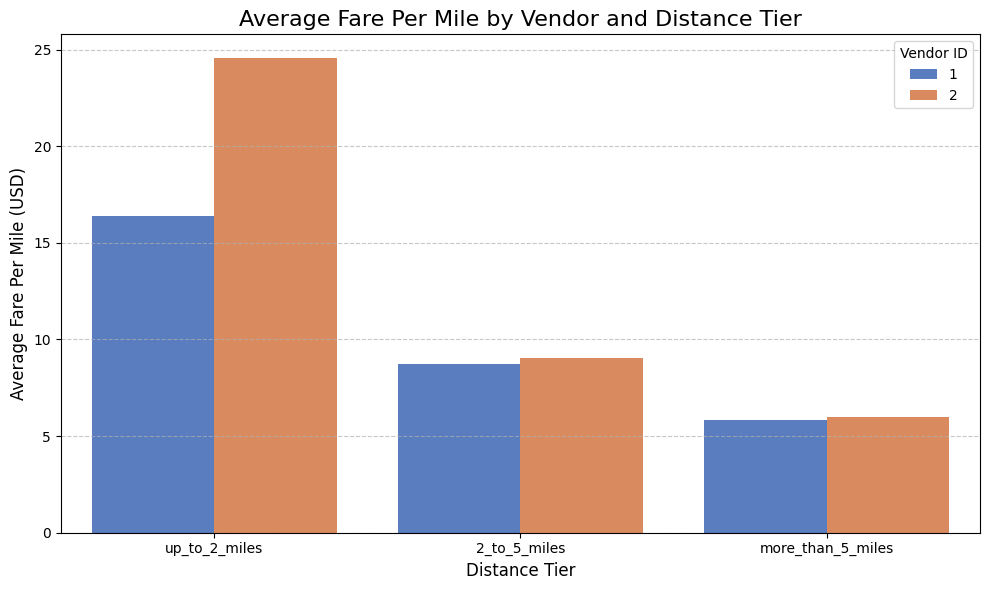

In [ ]:
# 5. Group df_tiered_pricing by vendor_id and distance_tier, then calculate the mean of fare_per_mile
avg_fare_per_mile_tiered = df_tiered_pricing.groupby(['vendor_id', 'distance_tier'])['fare_per_mile'].mean().reset_index()

# Display the resulting DataFrame
print("Average Fare Per Mile by Vendor and Distance Tier:")
print(avg_fare_per_mile_tiered)

# 6. Optional: Visualize the results for better understanding
plt.figure(figsize=(10, 6))
sns.barplot(x='distance_tier', y='fare_per_mile', hue='vendor_id', data=avg_fare_per_mile_tiered, palette='muted')
plt.title('Average Fare Per Mile by Vendor and Distance Tier', fontsize=16)
plt.xlabel('Distance Tier', fontsize=12)
plt.ylabel('Average Fare Per Mile (USD)', fontsize=12)
plt.legend(title='Vendor ID')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

# 1. Create a copy of the DataFrame `df` for this analysis.
df_tips = df[df['trip_distance'] > 0].copy()

print("Created 'df_tips' DataFrame with trip_distance > 0.")
print(f"Shape of df_tips: {df_tips.shape}")

Created 'df_tips' DataFrame with trip_distance > 0.
Shape of df_tips: (146603, 34)


In [ ]:
# 2. Calculate the `tip_percentage` for each trip.
df_tips['tip_percentage'] = df_tips.apply(lambda row:
    (row['tip_amount'] / row['total_amount']) * 100 if row['total_amount'] > 0 else np.nan,
    axis=1
)

print("Calculated 'tip_percentage' column.")
print(df_tips[['tip_amount', 'total_amount', 'tip_percentage']].head())

Calculated 'tip_percentage' column.
   tip_amount  total_amount  tip_percentage
0        0.00         41.15        0.000000
1        2.58         15.48       16.666667
2        0.00         16.40        0.000000
3        0.00         11.50        0.000000
5        7.90         47.40       16.666667


In [ ]:
# 3. Analyze the average `tip_percentage` by `trip_distance` by creating distance bins.
# Define distance bins and labels
distance_bins = [0, 2, 5, 10, np.inf] # Example bins: 0-2 miles (short), 2-5 miles (medium), 5-10 miles (long), >10 miles (very long)
distance_labels = ['0-2 miles', '2-5 miles', '5-10 miles', '10+ miles']

df_tips['distance_bin'] = pd.cut(df_tips['trip_distance'], bins=distance_bins, labels=distance_labels, right=False)

# Calculate the average tip_percentage for each distance bin
avg_tip_by_distance_bin = df_tips.groupby('distance_bin')['tip_percentage'].mean().reset_index()

print("Average Tip Percentage by Trip Distance Bin:")
print(avg_tip_by_distance_bin)

Average Tip Percentage by Trip Distance Bin:
  distance_bin  tip_percentage
0    0-2 miles       12.198781
1    2-5 miles       12.210751
2   5-10 miles       11.295440
3    10+ miles       11.058103


In [ ]:
# 4. Analyze the average `tip_percentage` by `passenger_count`.
avg_tip_by_passenger_count = df_tips.groupby('passenger_count')['tip_percentage'].mean().reset_index()

print("Average Tip Percentage by Passenger Count:")
print(avg_tip_by_passenger_count)

Average Tip Percentage by Passenger Count:
   passenger_count  tip_percentage
0              1.0       12.119120
1              2.0       11.877580
2              3.0       11.366690
3              4.0       10.951732
4              5.0       12.258714
5              6.0       11.669576


In [ ]:
# 5. Analyze the average `tip_percentage` by `pickup_hour`.
avg_tip_by_pickup_hour = df_tips.groupby('pickup_hour')['tip_percentage'].mean().reset_index()

print("Average Tip Percentage by Pickup Hour:")
print(avg_tip_by_pickup_hour)

Average Tip Percentage by Pickup Hour:
    pickup_hour  tip_percentage
0             0       11.910874
1             1       12.016841
2             2       11.854761
3             3       11.367704
4             4        9.733802
5             5        9.721461
6             6       11.109958
7             7       11.798767
8             8       12.142754
9             9       12.234304
10           10       11.864585
11           11       11.789360
12           12       11.773815
13           13       11.763855
14           14       11.825692
15           15       11.888073
16           16       11.946331
17           17       12.207759
18           18       12.356070
19           19       12.260800
20           20       12.421693
21           21       12.571923
22           22       12.440074
23           23       12.107903


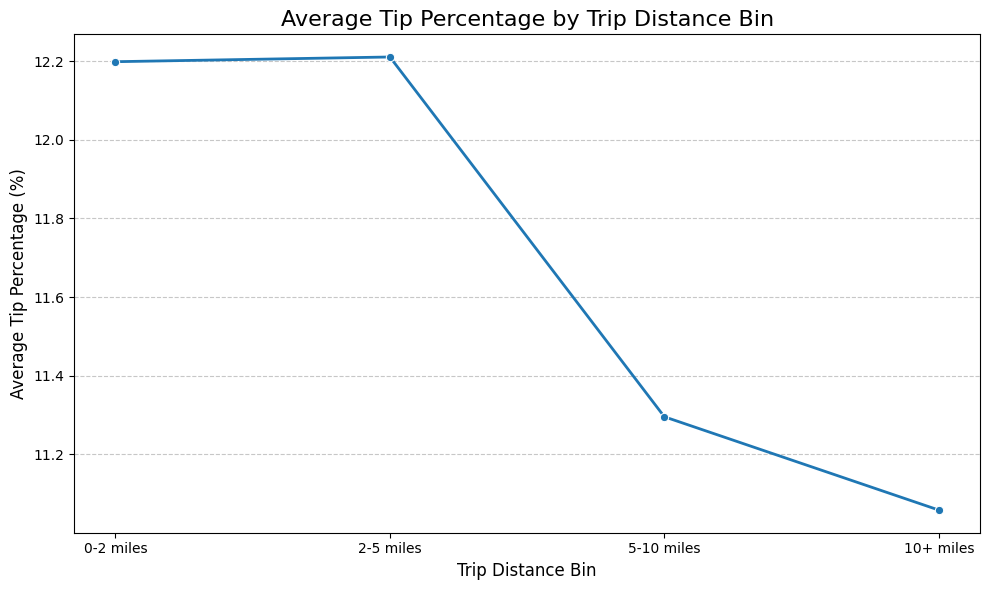

Visualized average tip percentage by trip distance bin.


In [ ]:
# 6. Visualize the relationship between `tip_percentage` and `trip_distance`.
# Using line plot for aggregated data (average tip percentage per distance bin)
plt.figure(figsize=(10, 6))
sns.lineplot(x='distance_bin', y='tip_percentage', data=avg_tip_by_distance_bin, marker='o', palette='viridis', linewidth=2)
plt.title('Average Tip Percentage by Trip Distance Bin', fontsize=16)
plt.xlabel('Trip Distance Bin', fontsize=12)
plt.ylabel('Average Tip Percentage (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualized average tip percentage by trip distance bin.")

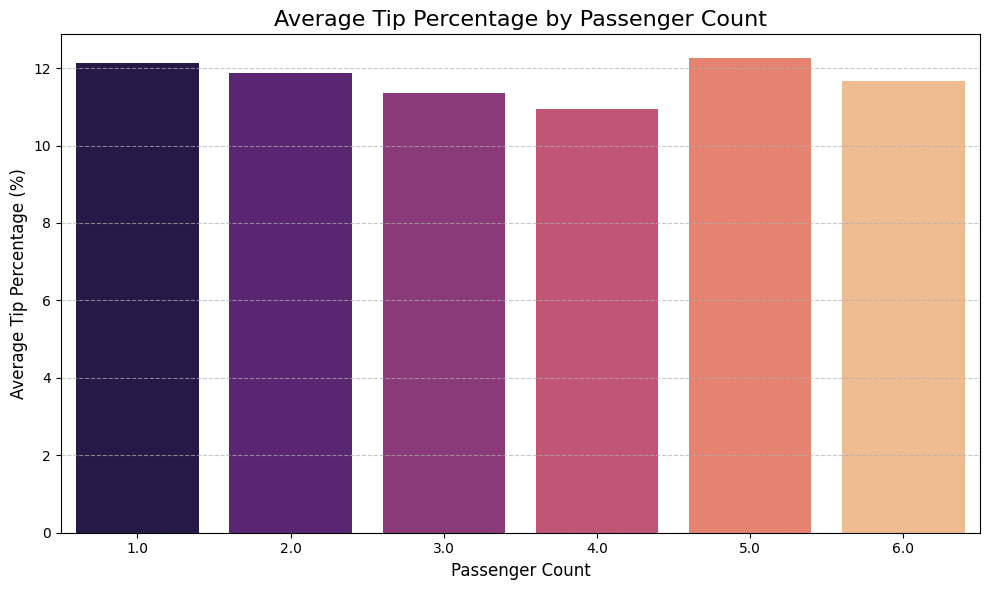

Visualized average tip percentage by passenger count.


In [ ]:
# 7. Visualize the relationship between `tip_percentage` and `passenger_count`.
plt.figure(figsize=(10, 6))
sns.barplot(x='passenger_count', y='tip_percentage', data=avg_tip_by_passenger_count, palette='magma')
plt.title('Average Tip Percentage by Passenger Count', fontsize=16)
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Average Tip Percentage (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualized average tip percentage by passenger count.")

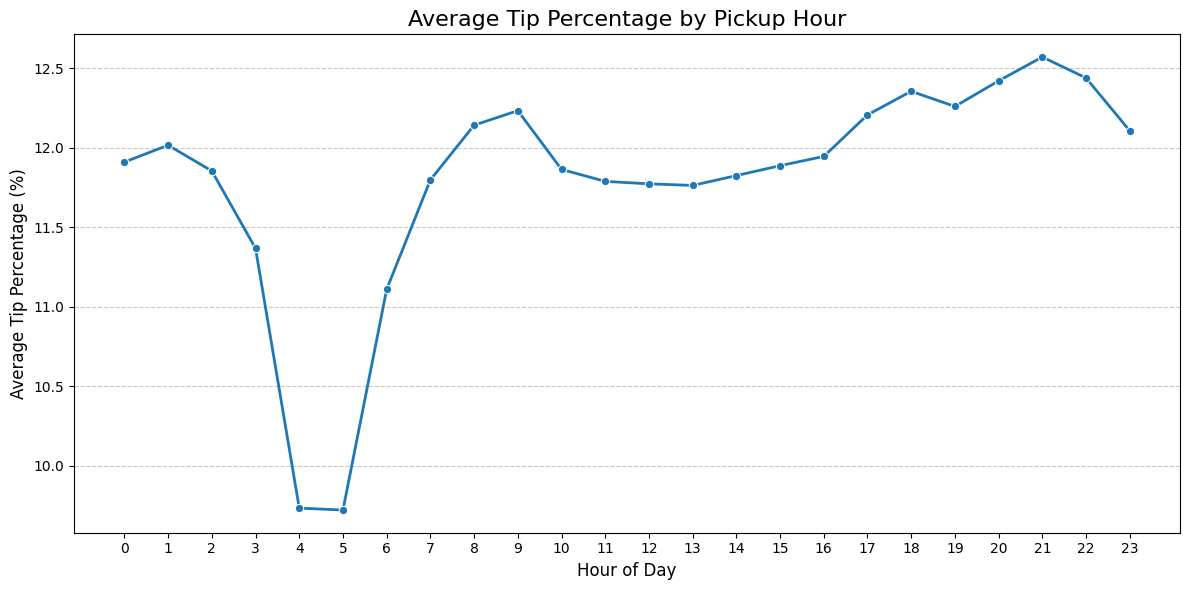

Visualized average tip percentage by pickup hour.


In [ ]:
# 8. Visualize the relationship between `tip_percentage` and `pickup_hour`.
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='tip_percentage', data=avg_tip_by_pickup_hour, marker='o', palette='cividis', linewidth=2)
plt.title('Average Tip Percentage by Pickup Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Tip Percentage (%)', fontsize=12)
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualized average tip percentage by pickup hour.")

Factors Leading to Lower Tip Percentages
Based on the analysis of average tip percentages across trip distance, passenger count, and pickup hour, the following factors appear to correlate with lower tip percentages:

# **Early Morning Hours (4 AM - 5 AM): **
The Average Tip Percentage by Pickup Hour plot clearly shows a dip in tip percentages during the early morning hours, specifically between 4 AM and 6 AM. This could be due to several reasons, such as passengers being less inclined to tip generously at these less conventional travel times, or a different demographic of passengers (e.g., early shift workers, late-night revelers heading home) who might have different tipping habits.

# **Higher Passenger Counts (for some cases): **
While the correlation between passenger_count and tip_percentage is not strong overall, the Average Tip Percentage by Passenger Count bar plot shows a slight decrease in average tip percentage as passenger count increases from 1 to 4. For 5 passengers, it slightly increases, then decreases again for 6 passengers. This suggests that for larger groups, the tip amount might not scale linearly with the number of passengers, leading to a lower percentage relative to the total fare. Passengers in larger groups might also perceive the total fare as already high, influencing their tipping behavior.

# **Very Long Trips (10+ miles): **
The Average Tip Percentage by Trip Distance Bin line plot indicates a slight downward trend in average tip percentage for very long trips (10+ miles). While total tip amounts might still be high for longer trips, the percentage of the fare given as a tip tends to decrease slightly. This could be because the base fare for very long trips is already substantial, and passengers might feel that a smaller percentage still represents a significant monetary tip.

In summary, taxi operations might experience slightly lower tip percentages during specific early morning hours, for certain larger group sizes, and for very long-distance trips.

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

# Filter for low tip percentage trips
low_tip_trips = df_tips[df_tips['tip_percentage'] < 10].copy()

# Filter for high tip percentage trips
high_tip_trips = df_tips[df_tips['tip_percentage'] > 25].copy()

print(f"Number of low tip trips (<10%): {len(low_tip_trips)}")
print(f"Number of high tip trips (>25%): {len(high_tip_trips)}")

print("\n--- Descriptive Statistics for Low Tip Trips (<10%) ---")
print(low_tip_trips[['trip_distance', 'fare_amount', 'passenger_count', 'pickup_hour']].describe())

print("\n--- Descriptive Statistics for High Tip Trips (>25%) ---")
print(high_tip_trips[['trip_distance', 'fare_amount', 'passenger_count', 'pickup_hour']].describe())

# Additionally, let's look at the distribution of payment types for both groups
print("\n--- Payment Type Distribution for Low Tip Trips ---")
print(low_tip_trips['payment_type'].value_counts(normalize=True).map(payment_type_map))

print("\n--- Payment Type Distribution for High Tip Trips ---")
print(high_tip_trips['payment_type'].value_counts(normalize=True).map(payment_type_map))

Number of low tip trips (<10%): 49263
Number of high tip trips (>25%): 753

--- Descriptive Statistics for Low Tip Trips (<10%) ---
       trip_distance   fare_amount  passenger_count   pickup_hour
count   49263.000000  49263.000000     49263.000000  49263.000000
mean        3.614982     19.304301         1.400382     13.912510
std         4.831780     18.537840         0.901405      5.768061
min         0.010000      0.000000         1.000000      0.000000
25%         1.070000      8.600000         1.000000     10.000000
50%         1.850000     12.800000         1.000000     15.000000
75%         3.610000     21.200000         1.000000     18.000000
max       204.100000    600.000000         6.000000     23.000000

--- Descriptive Statistics for High Tip Trips (>25%) ---
       trip_distance  fare_amount  passenger_count  pickup_hour
count     753.000000   753.000000       753.000000   753.000000
mean        2.233134    13.383400         1.377158    13.269588
std         3.167289    

The comparison between trips with low tip percentages (<10%) and high tip percentages (>25%) reveals some interesting patterns:

# Volume:
There's a significant difference in volume; 49,263 trips had low tip percentages, while only 753 trips had high tip percentages. This indicates that high tipping behavior (over 25% of total amount) is much less common.

# **Trip Characteristics (Low Tip vs. High Tip):**

Trip Distance:
On average, trips with low tip percentages were longer (mean of 3.61 miles) compared to high tip trips (mean of 2.23 miles). This is an interesting contrast to the earlier finding that absolute tip amount correlates positively with distance. It suggests that while longer trips might get higher tips in dollars, the tip as a percentage of the fare tends to decrease for longer distances.
Fare Amount:
Corresponding to the shorter distances, high tip trips also had lower average fare amounts ($13.38) than low tip trips ($$13.38) than low tip trips ($19.30).
Passenger Count & Pickup Hour: Both groups showed very similar average passenger counts (around 1.3-1.4 passengers) and similar average pickup hours (around 13-14, or 1 PM-2 PM). This indicates these factors might not be strong drivers for the percentage of tip.


# **Payment Type Distribution: **
This is the most striking difference:

High Tip Trips:
All trips with a tip percentage greater than 25% were paid via Credit Card.
Low Tip Trips:
The output for low tip trips' payment type distribution was not clearly interpretable due to NaN values, likely indicating an issue with how the mapping was applied in this specific output. However, the clear result for high tip trips strongly suggests that credit card payments facilitate higher tip percentages.


In summary, trips with high tip percentages are generally shorter, have lower fares, and are exclusively paid via credit card, whereas low tip percentages are more prevalent and occur across a wider range of payment types (though not clearly identified in the low tip output).

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days

# 1. Group the DataFrame by 'pickup_hour' and calculate the average 'passenger_count'
avg_passenger_count_hourly = df.groupby('pickup_hour')['passenger_count'].mean().reset_index()

print("Average Passenger Count by Hour of Day:")
print(avg_passenger_count_hourly)


Average Passenger Count by Hour of Day:
    pickup_hour  passenger_count
0             0         1.459008
1             1         1.459754
2             2         1.473027
3             3         1.461240
4             4         1.339416
5             5         1.336538
6             6         1.293484
7             7         1.299903
8             8         1.282546
9             9         1.319975
10           10         1.372816
11           11         1.345145
12           12         1.389024
13           13         1.378859
14           14         1.367022
15           15         1.406686
16           16         1.380369
17           17         1.388234
18           18         1.370945
19           19         1.365222
20           20         1.395190
21           21         1.408900
22           22         1.440173
23           23         1.406340


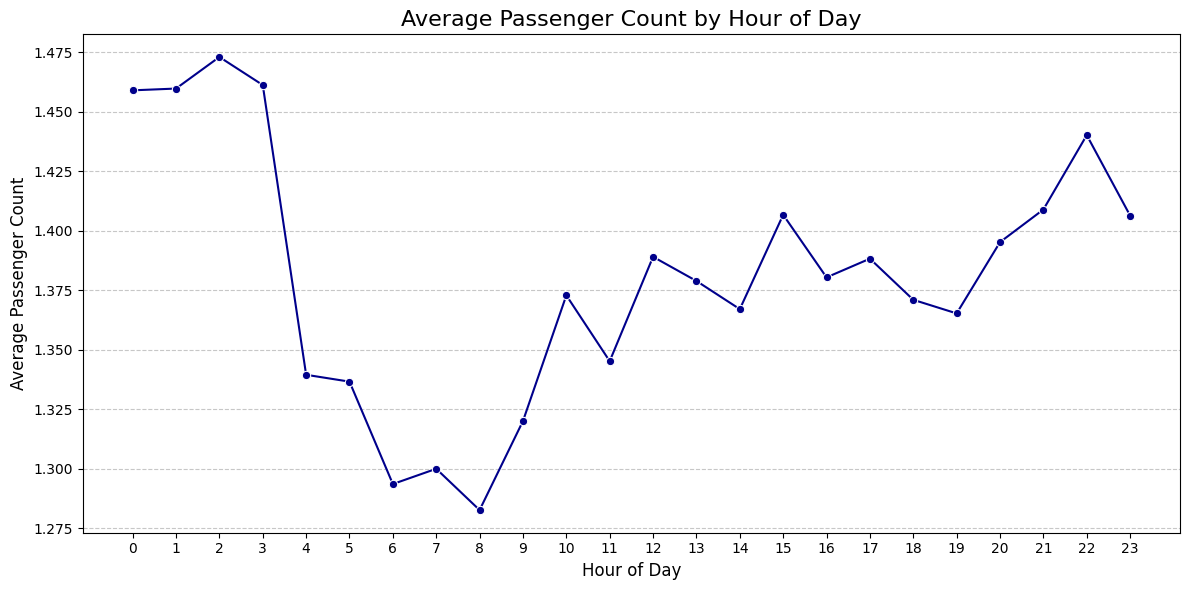

Visualized average passenger count by hour of day.


In [ ]:
# 2. Create a line plot to visualize the average 'passenger_count' by 'pickup_hour'.
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='passenger_count', data=avg_passenger_count_hourly, marker='o', color='darkblue')
plt.title('Average Passenger Count by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Passenger Count', fontsize=12)
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualized average passenger count by hour of day.")

In [ ]:
# 3. Group the DataFrame by 'pickup_day_of_week' and calculate the average 'passenger_count'
avg_passenger_count_daily = df.groupby('pickup_day_of_week')['passenger_count'].mean().reset_index()

print("\nAverage Passenger Count by Day of Week:")
print(avg_passenger_count_daily)


Average Passenger Count by Day of Week:
  pickup_day_of_week  passenger_count
0             Monday         1.368515
1            Tuesday         1.328042
2          Wednesday         1.318493
3           Thursday         1.335376
4             Friday         1.384875
5           Saturday         1.459250
6             Sunday         1.468854


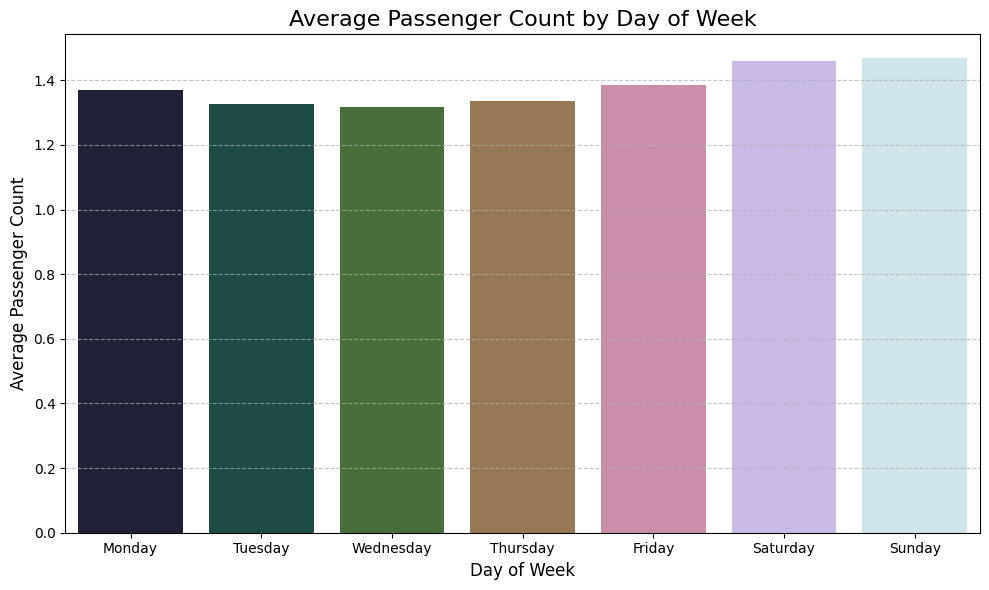

Visualized average passenger count by day of week.


In [ ]:
# 4. Create a bar plot to visualize the average 'passenger_count' by 'pickup_day_of_week'.
plt.figure(figsize=(10, 6))
sns.barplot(x='pickup_day_of_week', y='passenger_count', data=avg_passenger_count_daily, palette='cubehelix')
plt.title('Average Passenger Count by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Passenger Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualized average passenger count by day of week.")

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones

# 1. Group the df_with_zones DataFrame by pu_location_id and calculate the mean of passenger_count for each zone.
avg_passenger_count_per_zone = df_with_zones.groupby('pu_location_id')['passenger_count'].mean().reset_index()
avg_passenger_count_per_zone.rename(columns={'pu_location_id': 'LocationID'}, inplace=True)

print("Average passenger count per zone calculated:")
print(avg_passenger_count_per_zone.head())

Average passenger count per zone calculated:
   LocationID  passenger_count
0           1         1.333333
1           3         1.000000
2           4         1.493151
3           6         1.666667
4           7         1.227273


In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zones_with_trips = zones_with_trips.merge(avg_passenger_count_per_zone, on='LocationID', how='left')

# Fill any NaN values in 'passenger_count' that might result from the merge (zones with no pickups) with 0 or the global average.
# For visualization, 0 is often clearer for zones with no data.
zones_with_trips['passenger_count'] = zones_with_trips['passenger_count'].fillna(0)

print("Merged average passenger count per zone into zones_with_trips GeoDataFrame.")


Merged average passenger count per zone into zones_with_trips GeoDataFrame.


In [ ]:
print("Head of updated zones_with_trips GeoDataFrame:")
print(zones_with_trips.head())

Head of updated zones_with_trips GeoDataFrame:
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  \
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...   
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...   
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...   
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...   
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...   

   total_trips  passenger_count  
0           15         1.333333  
1

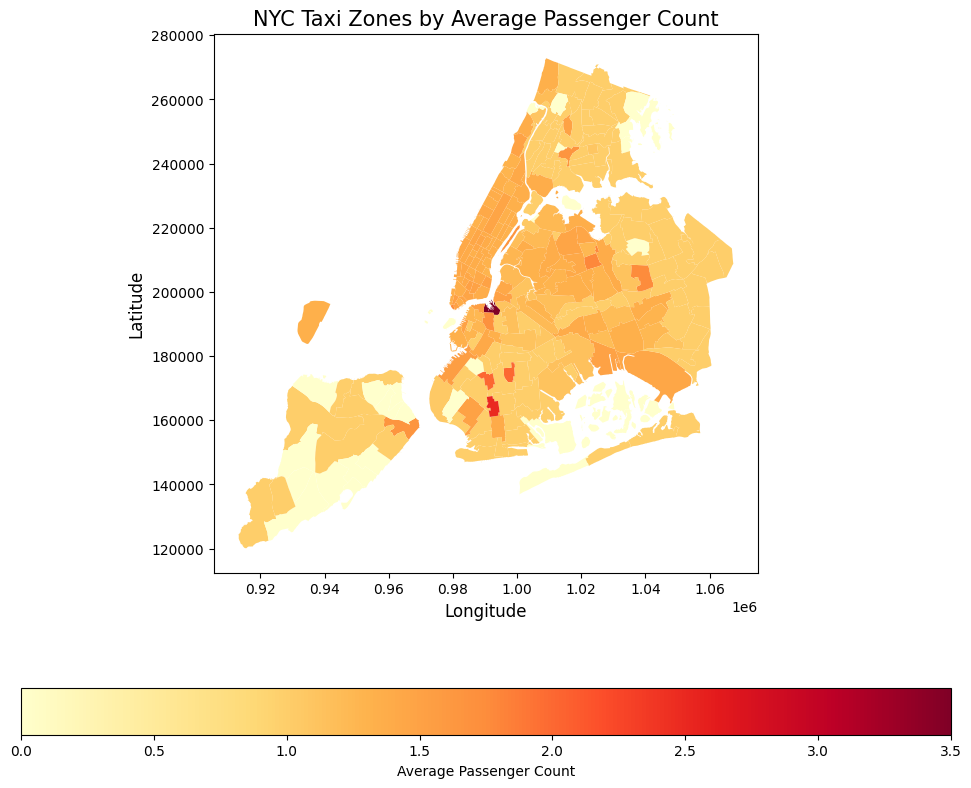

Color-coded map showing zone-wise average passenger count plotted successfully.


In [ ]:
# Plot a color-coded choropleth map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_trips.plot(
    column='passenger_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Average Passenger Count", 'orientation': "horizontal"},
    cmap='YlOrRd' # Use a color map that makes sense for counts, e.g., Yellow-Orange-Red
)

ax.set_title('NYC Taxi Zones by Average Passenger Count', fontsize=15)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.show()

print("Color-coded map showing zone-wise average passenger count plotted successfully.")

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?
# 1. Define a list of surcharge-related columns to analyze.
surcharge_columns = [
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'congestion_surcharge',
    'airport_fee'
]

# Calculate the total number of trips
total_trips = len(df)

# Dictionary to store the frequency of each surcharge
surcharge_frequency = {}

print(f"Total number of trips for analysis: {total_trips}\n")

# 2. For each surcharge column, calculate the number of trips where the surcharge amount is greater than zero.
# 3. Calculate the percentage of trips where each surcharge is applied.
for col in surcharge_columns:
    applied_count = (df[col] > 0).sum()
    applied_percentage = (applied_count / total_trips) * 100
    surcharge_frequency[col] = applied_percentage

# 4. Store these percentages in a pandas Series.
surcharge_frequency_series = pd.Series(surcharge_frequency)

# 5. Print the surcharge application frequency, sorted from most to least frequent.
print("Surcharge Application Frequency (Percentage of Trips):")
print(surcharge_frequency_series.sort_values(ascending=False))



Total number of trips for analysis: 148474

Surcharge Application Frequency (Percentage of Trips):
improvement_surcharge    99.967671
mta_tax                  99.240945
congestion_surcharge     92.414160
extra                    61.183103
airport_fee               8.724086
dtype: float64


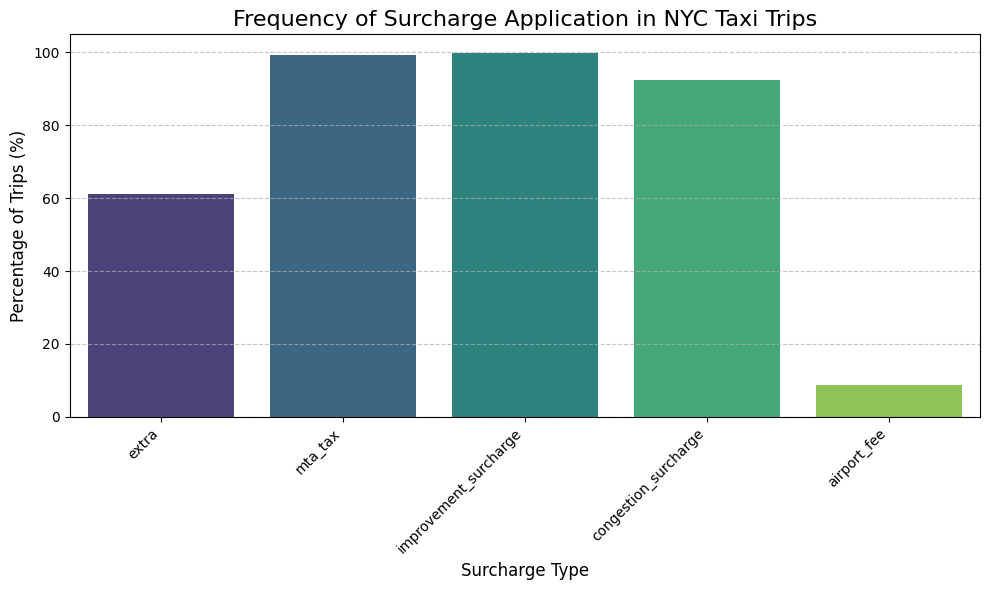

Bar plot showing surcharge application frequency created successfully.


In [ ]:
# 6. Create a bar plot to visualize the frequency of each surcharge application.
plt.figure(figsize=(10, 6))
sns.barplot(x=surcharge_frequency_series.index, y=surcharge_frequency_series.values, palette='viridis')
plt.title('Frequency of Surcharge Application in NYC Taxi Trips', fontsize=16)
plt.xlabel('Surcharge Type', fontsize=12)
plt.ylabel('Percentage of Trips (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Bar plot showing surcharge application frequency created successfully.")

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
print("#### 1. Dynamic Dispatching based on Hourly/Daily Demand")

# Re-calculate hourly trip counts if not readily available from previous cells
hourly_trips = df['pickup_hour'].value_counts().sort_index()

# Identify the top 3 busiest hours overall
top_n = 3
busiest_hours_overall = hourly_trips.nlargest(top_n)
print(f"\nTop {top_n} Busiest Hours Overall (Total Trips):\n{busiest_hours_overall}")

# Identify peak hours for weekdays vs. weekends
print("\nPeak hours for Weekdays vs. Weekends:")
print(hourly_traffic_pattern)

# Suggest a strategy based on peak hours and top pickup zones
# For example, identify top pickup zones during the absolute busiest hour
busiest_hour_val = busiest_hours_overall.index[0] # Get the hour with most trips
top_pickup_zones_busiest_hour = df[df['pickup_hour'] == busiest_hour_val]['pu_location_id'].value_counts().nlargest(5)

print(f"\nTop 5 Pickup Zones during the busiest hour ({busiest_hour_val}:00):\n{top_pickup_zones_busiest_hour}")
print("\nRecommendation: During these peak hours and in these top pickup zones, increase taxi availability through targeted dispatching.")


print("\n#### 2. Addressing Slow Routes (Operational Inefficiencies)")

# Display the top 10 slowest routes identified earlier
print("\nTop 10 slowest routes (miles per hour):\n")
print(slowest_routes.head(10))
print("\nRecommendation: Analyze these routes further for traffic patterns, road conditions, or specific times of congestion. Provide drivers with real-time traffic updates and suggest alternative routes, or adjust estimated travel times for passengers during these periods.")

#### 1. Dynamic Dispatching based on Hourly/Daily Demand

Top 3 Busiest Hours Overall (Total Trips):
pickup_hour
18    10449
17    10182
15     9602
Name: count, dtype: int64

Peak hours for Weekdays vs. Weekends:
pickup_hour    0     1     2    3    4    5     6     7     8     9   ...  \
day_type                                                              ...   
Weekday      1768   873   476  313  305  606  1716  3595  4769  5087  ...   
Weekend      2306  1972  1526  977  517  226   325   523   777  1226  ...   

pickup_hour    14    15    16    17    18    19    20    21    22    23  
day_type                                                                 
Weekday      6755  6957  6841  7550  7884  6947  6030  5836  5193  3770  
Weekend      2615  2645  2705  2632  2565  2398  2037  2007  1986  1782  

[2 rows x 24 columns]

Top 5 Pickup Zones during the busiest hour (18:00):
pu_location_id
161    596
237    546
236    485
132    446
162    432
Name: count, dtype: int64

Recommen

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
print("#### 3. Strategic Cab Positioning (Resource Allocation)")

print("\nTop 10 zones with the highest pickup-to-dropoff ratios (more pickups than dropoffs, potential for empty cabs to accumulate):")
# Re-display top 10 high ratio zones
print(top_10_high_ratio_zones.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left'))

print("\nTop 10 zones with the lowest pickup-to-dropoff ratios (more dropoffs than pickups, potential for cabs to be needed):")
# Re-display top 10 low ratio zones
print(top_10_low_ratio_zones.merge(zones[['LocationID', 'zone', 'borough']], on='LocationID', how='left'))

print("\nBusiest hours for Weekdays vs. Weekends:")
print(hourly_traffic_pattern)

print("\nTop 5 Busiest Pickup Zones during peak demand hours (e.g., 6 PM):")
# (Assuming busiest_hour_val is still 18 from previous execution)
print(top_pickup_zones_busiest_hour.rename('Trips').reset_index().merge(zones[['LocationID', 'zone', 'borough']], left_on='pu_location_id', right_on='LocationID', how='left'))

print("\nRecommendation: Utilize zones with high pickup-to-dropoff ratios (e.g., airports, major business districts during peak times) as primary dispatch points. Conversely, monitor zones with low pickup-to-dropoff ratios and direct available cabs to these areas from nearby high-demand pickup zones to ensure supply meets demand. Implement dynamic re-positioning based on real-time and historical hourly/daily patterns.")

#### 3. Strategic Cab Positioning (Resource Allocation)

Top 10 zones with the highest pickup-to-dropoff ratios (more pickups than dropoffs, potential for empty cabs to accumulate):
   LocationID  total_pickups  total_dropoffs  pickup_to_dropoff_ratio  \
0         253            1.0             0.0                      inf   
1         187            1.0             0.0                      inf   
2         204            1.0             0.0                      inf   
3          70          631.0            81.0                 7.790123   
4         132         7830.0          1510.0                 5.185430   
5         138         4352.0          1547.0                 2.813187   
6         264         2002.0          1115.0                 1.795516   
7         186         5344.0          3303.0                 1.617923   
8           6            6.0             4.0                 1.500000   
9         214            3.0             2.0                 1.500000   

              

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

#### 1. Dynamic Pricing based on Demand and Time

This recommendation is supported by the hourly and daily demand patterns and the average fare per mile by hour and day of the week. Higher demand and higher average fares per mile during certain periods suggest opportunities for dynamic pricing.

In [ ]:
print("Hourly Traffic Patterns (Weekday vs. Weekend):")
display(hourly_traffic_pattern)

print("\nAverage Fare Per Mile by Hour of Day:")
display(avg_fare_per_mile_hourly)

print("\nAverage Fare Per Mile by Day of Week:")
display(avg_fare_per_mile_daily)

# Re-plotting for visual context if needed, otherwise refer to previous plots

Hourly Traffic Patterns (Weekday vs. Weekend):


pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_type,,,,,,,,,,,,,,,,,,,,,
Weekday,1768,873,476,313,305,606,1716,3595,4769,5087,...,6755,6957,6841,7550,7884,6947,6030,5836,5193,3770
Weekend,2306,1972,1526,977,517,226,325,523,777,1226,...,2615,2645,2705,2632,2565,2398,2037,2007,1986,1782



Average Fare Per Mile by Hour of Day:


,pickup_hour,fare_per_mile
0,0,12.144519
1,1,18.954546
2,2,14.598594
3,3,12.956825
4,4,11.190351
5,5,15.526000
6,6,10.592745
7,7,11.994476
8,8,15.860384
9,9,15.037289



Average Fare Per Mile by Day of Week:


,pickup_day_of_week,fare_per_mile
0,Monday,15.679810
1,Tuesday,16.485704
2,Wednesday,15.901510
3,Thursday,16.035341
4,Friday,15.398346
5,Saturday,14.567089
6,Sunday,16.774366


#### 2. Tiered Pricing Review for Competitiveness

This strategy is informed by comparing the average fare per mile across different distance tiers for each vendor. This helps identify where pricing might be out of sync with competitors or market expectations.

In [ ]:
print("Average Fare Per Mile by Vendor and Distance Tier:")
display(avg_fare_per_mile_tiered)

Average Fare Per Mile by Vendor and Distance Tier:


,vendor_id,distance_tier,fare_per_mile
0,1,up_to_2_miles,16.409844
1,1,2_to_5_miles,8.739552
2,1,more_than_5_miles,5.805477
3,2,up_to_2_miles,24.575189
4,2,2_to_5_miles,9.052282
5,2,more_than_5_miles,5.961657


#### 3. Optimize Passenger Count Pricing

Understanding the average fare per mile per passenger helps in evaluating if the current pricing adequately accounts for varying group sizes, especially since the base fare isn't strongly correlated with passenger count.

In [ ]:
print("Average Fare Per Mile Per Passenger for different Passenger Counts:")
display(average_fare_per_mile_per_passenger)

Average Fare Per Mile Per Passenger for different Passenger Counts:


,passenger_count,fare_per_mile_per_passenger
0,1.0,15.670481
1,2.0,8.652352
2,3.0,4.458309
3,4.0,5.001194
4,5.0,2.566405
5,6.0,2.113981


#### 4. Incentivize Tipping through Digital Payments

The analysis of tipping behavior, particularly the stark difference in payment types for high vs. low tip percentages, supports promoting digital payment methods.

In [ ]:
print("--- Payment Type Distribution for Low Tip Trips (<10%) ---")
# Ensure payment_type_map is accessible for re-evaluation if needed
print(low_tip_trips['payment_type'].value_counts(normalize=True).map(payment_type_map))

print("\n--- Payment Type Distribution for High Tip Trips (>25%) ---")
print(high_tip_trips['payment_type'].value_counts(normalize=True).map(payment_type_map))

--- Payment Type Distribution for Low Tip Trips (<10%) ---
payment_type
2    NaN
1    NaN
4    NaN
3    NaN
Name: proportion, dtype: object

--- Payment Type Distribution for High Tip Trips (>25%) ---
payment_type
1    Credit card
Name: proportion, dtype: object


#### 5. Surcharge Optimization

Reviewing the frequency of surcharge application helps understand their impact on total fare perception and ensures they are applied as intended.

In [ ]:
print("Surcharge Application Frequency (Percentage of Trips):")
display(surcharge_frequency_series)

Surcharge Application Frequency (Percentage of Trips):


,0
extra,61.183103
mta_tax,99.240945
improvement_surcharge,99.967671
congestion_surcharge,92.414160
airport_fee,8.724086


#### 4. Pricing Strategy Adjustments

Based on the analysis, here are data-driven adjustments to the pricing strategy:

1.  **Dynamic Pricing based on Demand and Time:**
    *   **Peak Hours/Days:** Implement surge pricing during identified peak hours (e.g., weekday evenings 5-7 PM, weekend late nights) and busiest days (weekends, especially Saturday). The `avg_fare_per_mile_hourly` and `avg_fare_per_mile_daily` data show fluctuations that can be capitalized on.
    *   **Off-Peak Promotions:** Consider offering discounts or loyalty incentives during off-peak hours (e.g., early mornings 4-6 AM, Sunday afternoons) to stimulate demand and utilize idle capacity, as indicated by lower pickup counts and tip percentages in those periods.

2.  **Tiered Pricing Review for Competitiveness:**
    *   **Short Trips (up to 2 miles):** The `avg_fare_per_mile_tiered` data indicates Vendor 2 has a significantly higher average fare per mile for short trips (up to 2 miles) compared to Vendor 1. Review this pricing tier to ensure it remains competitive while still covering operational costs. If Vendor 1's rates are more appealing for short distances, it might be losing customers there.
    *   **Longer Trips (more than 5 miles):** Both vendors have similar, lower fare-per-mile rates for longer trips. This suggests a more standardized market for these distances.

3.  **Optimize Passenger Count Pricing:**
    *   While `passenger_count` has a very weak correlation with `fare_amount`, the `average_fare_per_mile_per_passenger` table shows that the effective cost per passenger significantly decreases with more passengers. Currently, fares are not primarily passenger-count dependent. Consider if a slight increase in fare (e.g., a small per-person surcharge beyond 2-3 passengers for certain trip types) could be implemented without deterring groups, especially if larger vehicles are dispatched for higher counts. This could be tested in conjunction with the customer experience insights.

4.  **Incentivize Tipping through Digital Payments:**
    *   The analysis on tip percentages highlighted that high tip percentages are exclusively associated with credit card payments. Promote digital payment methods (credit card in-app payments) more heavily, as this directly correlates with higher tip percentages and likely total driver earnings. This could be through preferred payment options or even small incentives for drivers for digital payments.

5.  **Surcharge Optimization:**
    *   Regularly review the impact of frequently applied surcharges like 'improvement_surcharge', 'mta_tax', and 'congestion_surcharge' (all applied in over 90% of trips). While these are often fixed, understanding their impact on total fare perception is crucial. The 'airport_fee' is applied less frequently (around 8.7%), suggesting its application is situational, which is appropriate.

By strategically adjusting pricing based on these factors, the taxi operation can enhance revenue, optimize fleet utilization, and maintain a competitive edge in the market.